# Task 1: Performance vs Carbon Cost

**Goal**: For each dataset, plot a scatter where every point is a model:  
- X-axis: total CO₂eq emitted for the full run (in **grams**, matching CarbonTracker output)  
- Y-axis: Macro F1 score (averaged across all prompt strategies for that model)  
- Color: model family  
- Label: model name  

**Open models** (Qwen3, Llama, etc.): carbon comes directly from CarbonTracker logs.  
**Closed models** (GPT, Claude): carbon is estimated via EcoLogits — result is converted to grams to match.  

We produce **one separate figure per dataset**: SemEval 2016, EZStance, MTCSD.

## 1. Imports

In [1]:
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# EcoLogits is used ONLY for estimating carbon of closed (GPT, Claude) models
from ecologits import EcoLogits
EcoLogits.init(providers=['openai', 'anthropic'])
from ecologits.tracers.utils import llm_impacts

# adjustText moves labels apart so they don't overlap on scatter plots
from adjustText import adjust_text

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 2. Configuration

All paths, model-family assignments, and colors are defined here.  
If you add a new model, add it to `MODEL_FAMILY` (and optionally `MODEL_LABELS`).

In [2]:
BASE = '/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance'

# Folder for each dataset's results.
# MTCSD is split across two directories:
#   - mtcsd_test_results: existing vllm/GPT runs
#   - mtcsd_test: where new Claude runs land (output_dir derived from data_in/mtcsd_test.csv)
# load_all_runs handles a list of dirs by scanning all of them.
DATASET_DIRS = {
    'SemEval 2016':  [os.path.join(BASE, 'semeval_results')],
    'EZStance':      [os.path.join(BASE, 'ezstance_test')],
    'MTCSD':         [os.path.join(BASE, 'mtcsd_test_results'),
                      os.path.join(BASE, 'mtcsd_test')],
}

# Which model belongs to which family?
# Open (vllm) models — carbon from CarbonTracker
MODEL_FAMILY = {
    'Qwen3-1.7B':                    'Qwen3',
    'Qwen3-4B':                      'Qwen3',
    'Qwen3-4B-Instruct-2507':        'Qwen3',
    'Qwen3-8B':                      'Qwen3',
    'Qwen3-14B':                     'Qwen3',
    'Qwen3-32B':                     'Qwen3',
    'DeepSeek-R1-Distill-Llama-8B':  'DeepSeek',
    'DeepSeek-R1-Distill-Qwen-14B':  'DeepSeek',
    'DeepSeek-R1-Distill-Qwen-32B':  'DeepSeek',
    'Llama-3.1-8B-Instruct':         'Llama',
    'phi-4':                         'Phi',
    'phi-4-mini-instruct':           'Phi',
    'Nemotron-Mini-4B-Instruct':     'Nemotron',
    'AI21-Jamba2-3B':                'Other',
    # Closed (API) models — carbon estimated via EcoLogits
    'gpt-5-mini':                    'GPT (closed)',
    'gpt-5.2':                       'GPT (closed)',
    'claude-haiku-4-5-20251001':     'Claude (closed)',
}

# Shorter display names for labels on the plot
MODEL_LABELS = {
    'Qwen3-1.7B':                    'Qwen3-1.7B',
    'Qwen3-4B':                      'Qwen3-4B',
    'Qwen3-4B-Instruct-2507':        'Qwen3-4B-IT',
    'Qwen3-8B':                      'Qwen3-8B',
    'Qwen3-14B':                     'Qwen3-14B',
    'Qwen3-32B':                     'Qwen3-32B',
    'DeepSeek-R1-Distill-Llama-8B':  'DS-Llama-8B',
    'DeepSeek-R1-Distill-Qwen-14B':  'DS-Qwen-14B',
    'DeepSeek-R1-Distill-Qwen-32B':  'DS-Qwen-32B',
    'Llama-3.1-8B-Instruct':         'Llama-3.1-8B',
    'phi-4':                         'phi-4',
    'phi-4-mini-instruct':           'phi-4-mini',
    'Nemotron-Mini-4B-Instruct':     'Nemotron-4B',
    'AI21-Jamba2-3B':                'Jamba2-3B',
    'gpt-5-mini':                    'gpt-5-mini †',
    'gpt-5.2':                       'gpt-5.2 †',
    'claude-haiku-4-5-20251001':     'Claude-Haiku-4.5 †',
}

# One color per family
FAMILY_COLORS = {
    'Qwen3':           '#4C72B0',   # blue
    'DeepSeek':        '#C44E52',   # red
    'Llama':           '#DD8452',   # orange
    'Phi':             '#55A868',   # green
    'Nemotron':        '#8172B2',   # purple
    'Other':           '#937860',   # brown
    'GPT (closed)':    '#E8468A',   # pink
    'Claude (closed)': '#1B9AAA',   # teal
}

In [3]:
CARBON_CSV = '/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/carbon_audit.csv'
carbon_lookup_df = pd.read_csv(CARBON_CSV)

# Fast lookups keyed on (dataset, model, prompt)
_carbon_index     = carbon_lookup_df.set_index(['dataset','model','prompt'])['co2_g']
_throughput_index = carbon_lookup_df.set_index(['dataset','model','prompt'])['throughput_tok_s']
_docs_ps_index    = carbon_lookup_df.set_index(['dataset','model','prompt'])['docs_per_sec']

def _lookup(index, dataset, model, prompt):
    try:
        val = index.loc[(dataset, model, prompt)]
        return float(val) if pd.notna(val) else None
    except KeyError:
        return None

def lookup_carbon(dataset, model, prompt):
    return _lookup(_carbon_index, dataset, model, prompt)

def lookup_throughput(dataset, model, prompt):
    return _lookup(_throughput_index, dataset, model, prompt)

def lookup_docs_per_sec(dataset, model, prompt):
    return _lookup(_docs_ps_index, dataset, model, prompt)

print(f"Audit CSV loaded: {len(carbon_lookup_df)} rows")
print(carbon_lookup_df.groupby('dataset')[['model']].nunique().rename(columns={'model':'n_models'}))

Audit CSV loaded: 509 rows
              n_models
dataset               
EZStance            13
MTCSD               14
SemEval 2016        14


## 3. Helper Functions

Three functions:

1. **`normalize_label`** — converts raw stance strings to canonical FAVOR/AGAINST/NONE.  
2. **`compute_macro_f1`** — given a document_assignments CSV, computes macro-averaged F1.  
3. **`get_carbon_grams`** — extracts total CO₂eq in **grams** for a single experiment folder.  
   - If it's an open model: reads the CarbonTracker `_output.log` file.  
   - If it's a closed model: calls EcoLogits and converts kgCO2eq → grams.  

4. **`load_all_runs`** — walks a dataset folder and returns one row per experiment run.

In [4]:
def normalize_label(x):
    if pd.isna(x): return None
    s = str(x).strip().upper()
    if s == 'FAVOR':                        return 'FAVOR'
    if s == 'AGAINST':                      return 'AGAINST'
    if s in ('NONE', 'NEUTRAL', 'NEITHER'): return 'NONE'
    return None


def compute_macro_f1(assignments_csv_path):
    df = pd.read_csv(assignments_csv_path)
    if 'run' in df.columns:
        df = df[df['run'] == 0]
    df['true'] = df['original_stance'].apply(normalize_label)
    df['pred'] = df['predicted_stance'].apply(normalize_label)
    valid = df[df['true'].notna() & df['pred'].notna()]
    if len(valid) < 10: return None
    f1_per_class = f1_score(valid['true'], valid['pred'],
                            labels=['FAVOR','AGAINST','NONE'],
                            average=None, zero_division=0)
    return float(f1_per_class.mean())


def get_carbon_grams_closed(summary_path):
    s    = json.load(open(summary_path))
    cfg  = s.get('configuration', {})
    runs = s.get('runs', [])
    if not runs: return None
    run0    = runs[0]
    backend = cfg.get('llm_backend', '')
    if backend == 'openai':
        usage, provider, model_name = (run0.get('openai_usage') or {}), 'openai', cfg.get('openai_model','')
    elif backend == 'claude':
        usage, provider, model_name = (run0.get('claude_usage') or {}), 'anthropic', cfg.get('claude_model','')
    else:
        return None
    out_tokens = usage.get('completion_tokens') or usage.get('output_tokens')
    latency    = run0.get('runtime_seconds')
    if not out_tokens or not latency: return None
    try:
        result = llm_impacts(provider=provider, model_name=model_name,
                             output_token_count=int(out_tokens), request_latency=float(latency))
    except Exception:
        return None
    if result is None or result.gwp is None: return None
    gwp = result.gwp.value
    if hasattr(gwp, 'min'):
        return ((gwp.min + gwp.max) / 2) * 1000
    return gwp * 1000


def load_all_runs(dataset_dir, dataset_name):
    """
    Walk experiment folders. F1 computed from document_assignments.csv.
    Carbon + throughput for open models from carbon_audit.csv lookup.
    Carbon for closed models via EcoLogits; throughput from summary.json.
    """
    rows = []
    for folder_name in sorted(os.listdir(dataset_dir)):
        folder_path      = os.path.join(dataset_dir, folder_name)
        summary_path     = os.path.join(folder_path, 'summary.json')
        assignments_path = os.path.join(folder_path, 'document_assignments.csv')
        if not (os.path.isdir(folder_path)
                and os.path.exists(summary_path)
                and os.path.exists(assignments_path)):
            continue

        s    = json.load(open(summary_path))
        cfg  = s.get('configuration', {})
        runs = s.get('runs', [])
        if not runs: continue
        run0 = runs[0]

        backend = cfg.get('llm_backend', '')
        if backend == 'vllm':
            model, is_open = cfg.get('vllm_model','').split('/')[-1], True
        elif backend == 'openai':
            model, is_open = cfg.get('openai_model',''), False
        elif backend == 'claude':
            model, is_open = cfg.get('claude_model',''), False
        else:
            continue

        prompt = cfg.get('stance_prompt_name', 'unknown')

        try:    f1 = compute_macro_f1(assignments_path)
        except: f1 = None
        if f1 is None: continue

        if is_open:
            co2_g      = lookup_carbon(dataset_name, model, prompt)
            throughput = lookup_throughput(dataset_name, model, prompt)
            docs_ps    = lookup_docs_per_sec(dataset_name, model, prompt)
        else:
            co2_g      = get_carbon_grams_closed(summary_path)
            throughput = run0.get('throughput_tokens_per_sec')
            num_ex     = run0.get('num_examples')
            runtime    = run0.get('runtime_seconds')
            docs_ps    = (num_ex / runtime) if (num_ex and runtime) else None

        rows.append({'dataset': dataset_name, 'model': model, 'prompt': prompt,
                     'macro_f1': f1, 'co2_g': co2_g, 'is_open': is_open,
                     'throughput_tok_s': throughput, 'docs_per_sec': docs_ps})

    print(f'  {dataset_name}: {len(rows)} valid runs loaded')
    return pd.DataFrame(rows)

## 4. Load Data for All Three Datasets

This scans every result folder and builds one row per experiment run.  
We'll see the count of valid runs for each dataset printed below.

In [5]:
print('Loading all runs...')

frames = []
for name, dirs in DATASET_DIRS.items():
    # dirs is a list; scan each one and combine
    dataset_frames = []
    for d in dirs:
        if os.path.isdir(d):
            dataset_frames.append(load_all_runs(d, name))
    if dataset_frames:
        frames.append(pd.concat(dataset_frames, ignore_index=True))

all_runs = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows: {len(all_runs)}')
print('\nSample (first 5 rows):')
display(all_runs.head())

Loading all runs...


The model architecture has not been released, expect lower precision. For further information visit https://ecologits.ai/tutorial/warnings_and_errors/#model-arch-not-released
The model architecture is multimodal, expect lower precision. For further information visit https://ecologits.ai/tutorial/warnings_and_errors/#model-arch-multimodal


  SemEval 2016: 222 valid runs loaded
  EZStance: 154 valid runs loaded
  MTCSD: 142 valid runs loaded
  MTCSD: 11 valid runs loaded

Total rows: 529

Sample (first 5 rows):


,dataset,model,prompt,macro_f1,co2_g,is_open,throughput_tok_s,docs_per_sec
0,SemEval 2016,DeepSeek-R1-Distill-Llama-8B,cot,0.574181,4.132363,True,11297.17,11.252252
1,SemEval 2016,DeepSeek-R1-Distill-Llama-8B,default,0.546011,4.687608,True,3131.71,6.122549
2,SemEval 2016,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,0.584589,4.544556,True,3112.46,6.751351
3,SemEval 2016,DeepSeek-R1-Distill-Llama-8B,few_shot_12,0.549675,1.402461,True,24770.86,24.490196
4,SemEval 2016,DeepSeek-R1-Distill-Llama-8B,few_shot_15,0.552038,1.389995,True,29140.39,25.489796


## 5. Aggregate: One Point per Model per Dataset

Each model has been run with multiple prompt strategies.  
We average `macro_f1` and `co2_g` across all prompts to get a single representative point.  
We also keep `std_f1` so we can draw error bars (±1 std) to show how much the score varies across prompts.

In [6]:
all_runs_consistent = all_runs[all_runs['macro_f1'].notna() & all_runs['co2_g'].notna()].copy()

dropped = len(all_runs) - len(all_runs_consistent)
if dropped:
    print(f"Dropped {dropped} rows missing F1 or carbon:")
    print(all_runs[~(all_runs['macro_f1'].notna() & all_runs['co2_g'].notna())][['dataset','model','prompt','macro_f1','co2_g']])
else:
    print("All rows have both F1 and carbon — no data dropped.")

model_stats = (
    all_runs_consistent
    .groupby(['dataset', 'model', 'is_open'])
    .agg(
        n_prompts        = ('macro_f1',        'count'),
        avg_f1           = ('macro_f1',         'mean'),
        std_f1           = ('macro_f1',         'std'),
        avg_co2_g        = ('co2_g',            'mean'),
        avg_throughput   = ('throughput_tok_s',  'mean'),
        avg_docs_per_sec = ('docs_per_sec',      'mean'),
    )
    .reset_index()
)

model_stats['label']  = model_stats['model'].map(MODEL_LABELS).fillna(model_stats['model'])
model_stats['family'] = model_stats['model'].map(MODEL_FAMILY).fillna('Other')
model_stats['color']  = model_stats['family'].map(FAMILY_COLORS).fillna('#888')
model_stats['std_f1'] = model_stats['std_f1'].fillna(0)

_f1_max = model_stats['avg_f1'].max()
GLOBAL_YMIN   = 0.20
GLOBAL_YMAX   = max(0.80, np.ceil(_f1_max / 0.05) * 0.05 + 0.01)  # floor at 0.8 so top points/error bars aren't cut off
GLOBAL_YTICKS = np.arange(0.20, GLOBAL_YMAX, 0.05)

_co2_max = model_stats['avg_co2_g'].max()
GLOBAL_XMAX   = np.ceil(_co2_max / 5) * 5 + 2
GLOBAL_XTICKS = np.arange(0, GLOBAL_XMAX, 5)

print(f'\nY range: {GLOBAL_YMIN:.2f} → {GLOBAL_YMAX:.2f}')
print(f'X range: 0 → {GLOBAL_XMAX:.0f}')
print(f'Throughput range: {model_stats["avg_throughput"].min():.0f} – {model_stats["avg_throughput"].max():.0f} tok/s')

print('\nSummary table:')
display(
    model_stats[['dataset','model','family','n_prompts','avg_f1','std_f1','avg_co2_g','avg_throughput','avg_docs_per_sec']]
    .sort_values(['dataset','avg_f1'], ascending=[True, False])
    .reset_index(drop=True)
    .style.format({'avg_f1':'{:.3f}','std_f1':'{:.3f}','avg_co2_g':'{:.2f}',
                   'avg_throughput':'{:.0f}','avg_docs_per_sec':'{:.2f}'})
)

All rows have both F1 and carbon — no data dropped.

Y range: 0.20 → 0.76
X range: 0 → 62
Throughput range: 160 – 61935 tok/s

Summary table:


,dataset,model,family,n_prompts,avg_f1,std_f1,avg_co2_g,avg_throughput,avg_docs_per_sec
0,EZStance,gpt-5.2,GPT (closed),11,0.605,0.042,35.73,2963,7.41
1,EZStance,DeepSeek-R1-Distill-Qwen-14B,DeepSeek,11,0.603,0.015,5.95,12716,17.54
2,EZStance,claude-haiku-4-5-20251001,Claude (closed),11,0.598,0.026,3.61,191,0.42
3,EZStance,gpt-5-mini,GPT (closed),11,0.591,0.055,59.03,2800,4.71
4,EZStance,Qwen3-14B,Qwen3,11,0.588,0.088,9.45,10002,11.54
5,EZStance,phi-4,Phi,11,0.583,0.032,2.12,23504,45.07
6,EZStance,Qwen3-8B,Qwen3,11,0.579,0.093,7.67,14559,14.95
7,EZStance,Qwen3-4B,Qwen3,11,0.564,0.092,5.93,18734,20.19
8,EZStance,DeepSeek-R1-Distill-Llama-8B,DeepSeek,11,0.564,0.026,3.73,21140,28.08
9,EZStance,phi-4-mini-instruct,Phi,11,0.557,0.030,0.58,50267,110.03


## 6. Task 1 Plots — CO₂eq vs Macro F1

One figure per dataset.  
- **X-axis**: average CO₂eq in **grams** across all prompt strategies (CarbonTracker for open models; EcoLogits midpoint estimate for closed models — same unit).  
- **Y-axis**: average macro-F1 (error bars = ±1 std across prompt strategies).  
- Points are colored by model family; closed models are marked with †.  
- Labels are automatically adjusted to avoid overlap.

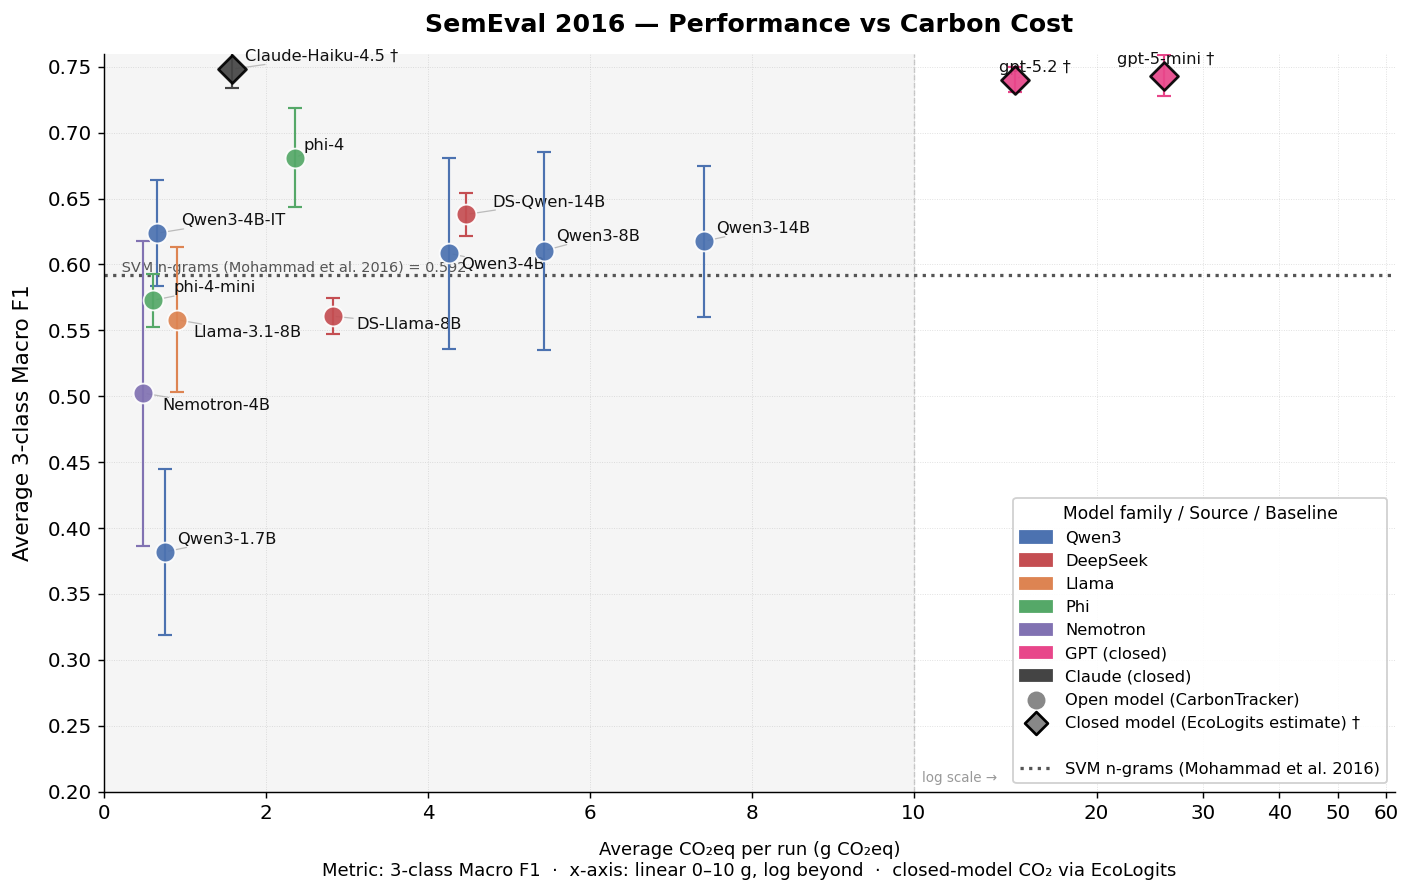

In [7]:
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

SUPERVISED_BASELINES = {
    'SemEval 2016': [('SVM n-grams (Mohammad et al. 2016)', 0.5921)],
    'EZStance':     [('BART-MNLI-ep fine-tuned (EZStance paper)', 0.687)],
    'MTCSD':        [],
}

# X-axis: linear 0–10, log beyond 10 (symlog).
# Ticks are hand-picked for readability in both regions.
SYMLOG_THRESH  = 10
X_TICKS_LINEAR = [0, 2, 4, 6, 8, 10]
X_TICKS_LOG    = [20, 30, 40, 50, 60, 80, 100]   # trimmed to GLOBAL_XMAX in the function


def plot_co2_vs_f1(dataset_name, ax=None, save_path=None, stats_df=None, error_bars=True):
    """
    Scatter plot: x = avg CO2 (g), y = avg macro-F1.
    X-axis uses a symlog scale: linear 0-10, log beyond 10.
    error_bars: if True, draw ±1 std bars across prompt strategies.
    """
    if stats_df is None:
        stats_df = model_stats

    subset = stats_df[
        (stats_df['dataset'] == dataset_name) &
        stats_df['avg_co2_g'].notna()
    ].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 7))
    else:
        fig = ax.get_figure()

    # ── Symlog x-axis ─────────────────────────────────────────────────────────
    ax.set_xscale('symlog', linthresh=SYMLOG_THRESH, linscale=1.2)

    # Shade the linear region so readers immediately see the scale change
    ax.axvspan(0, SYMLOG_THRESH, color='#f5f5f5', zorder=0)
    ax.axvline(SYMLOG_THRESH, color='#cccccc', linewidth=0.8, linestyle='--', zorder=1)
    ax.text(SYMLOG_THRESH + 0.3, GLOBAL_YMIN + 0.005, 'log scale →',
            fontsize=7.5, color='#999', va='bottom')

    # Custom ticks: fine-grained in linear region, sparse in log region
    xticks = X_TICKS_LINEAR + [t for t in X_TICKS_LOG if t <= GLOBAL_XMAX]
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

    # ── Supervised baseline lines ─────────────────────────────────────────────
    baseline_handles = []
    for label, value in SUPERVISED_BASELINES.get(dataset_name, []):
        ax.axhline(value, linestyle=':', linewidth=1.8, color='#555', zorder=2)
        ax.text(0.01, value, f' {label} = {value:.3f}',
                transform=ax.get_yaxis_transform(),
                fontsize=8, color='#555', va='bottom')
        baseline_handles.append(
            plt.Line2D([0], [0], linestyle=':', color='#555', linewidth=1.8, label=label)
        )

    # ── Model scatter points ──────────────────────────────────────────────────
    texts = []
    for _, row in subset.iterrows():
        marker    = 'D' if not row['is_open'] else 'o'
        edgecolor = 'black' if not row['is_open'] else 'white'
        linewidth = 1.5 if not row['is_open'] else 1.0

        if error_bars:
            ax.errorbar(
                row['avg_co2_g'], row['avg_f1'],
                yerr=row['std_f1'],
                fmt='none', color=row['color'],
                capsize=4, capthick=1.2, elinewidth=1.2, zorder=3,
            )
        ax.scatter(
            row['avg_co2_g'], row['avg_f1'],
            s=120, color=row['color'], marker=marker,
            edgecolors=edgecolor, linewidths=linewidth,
            alpha=0.92, zorder=4,
        )
        texts.append(ax.text(row['avg_co2_g'], row['avg_f1'], row['label'],
                             fontsize=9, color='#111'))

    adjust_text(texts, ax=ax, expand=(1.4, 1.8),
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7))

    # ── Y-axis ────────────────────────────────────────────────────────────────
    ax.set_xlim(0, GLOBAL_XMAX)
    ax.set_ylim(GLOBAL_YMIN, GLOBAL_YMAX)
    ax.set_yticks(GLOBAL_YTICKS)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

    # ── Labels and styling ────────────────────────────────────────────────────
    ax.set_ylabel('Average 3-class Macro F1', fontsize=12, labelpad=8)
    ax.set_title(f'{dataset_name} — Performance vs Carbon Cost',
                 fontsize=14, fontweight='bold', pad=12)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.4, color='#aaa')
    ax.spines[['top', 'right']].set_visible(False)

    has_closed = (~subset['is_open']).any()
    subtitle_parts = ['Metric: 3-class Macro F1', 'x-axis: linear 0–10 g, log beyond']
    if has_closed:
        subtitle_parts.append('closed-model CO₂ via EcoLogits')
    ax.set_xlabel(
        'Average CO₂eq per run (g CO₂eq)\n' + '  ·  '.join(subtitle_parts),
        fontsize=10, labelpad=10,
    )

    # ── Legend ────────────────────────────────────────────────────────────────
    families_present = subset['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in families_present
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (CarbonTracker)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (EcoLogits estimate) †'),
    ]
    all_handles = family_handles + marker_handles
    if baseline_handles:
        all_handles += [mpatches.Patch(color='none', label='')] + baseline_handles

    ax.legend(handles=all_handles, fontsize=9,
              title='Model family / Source / Baseline', title_fontsize=9.5,
              loc='best', framealpha=0.9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')
    return fig, ax


# ── SemEval 2016 ──────────────────────────────────────────────────────────────
fig, ax = plot_co2_vs_f1('SemEval 2016')
plt.show()

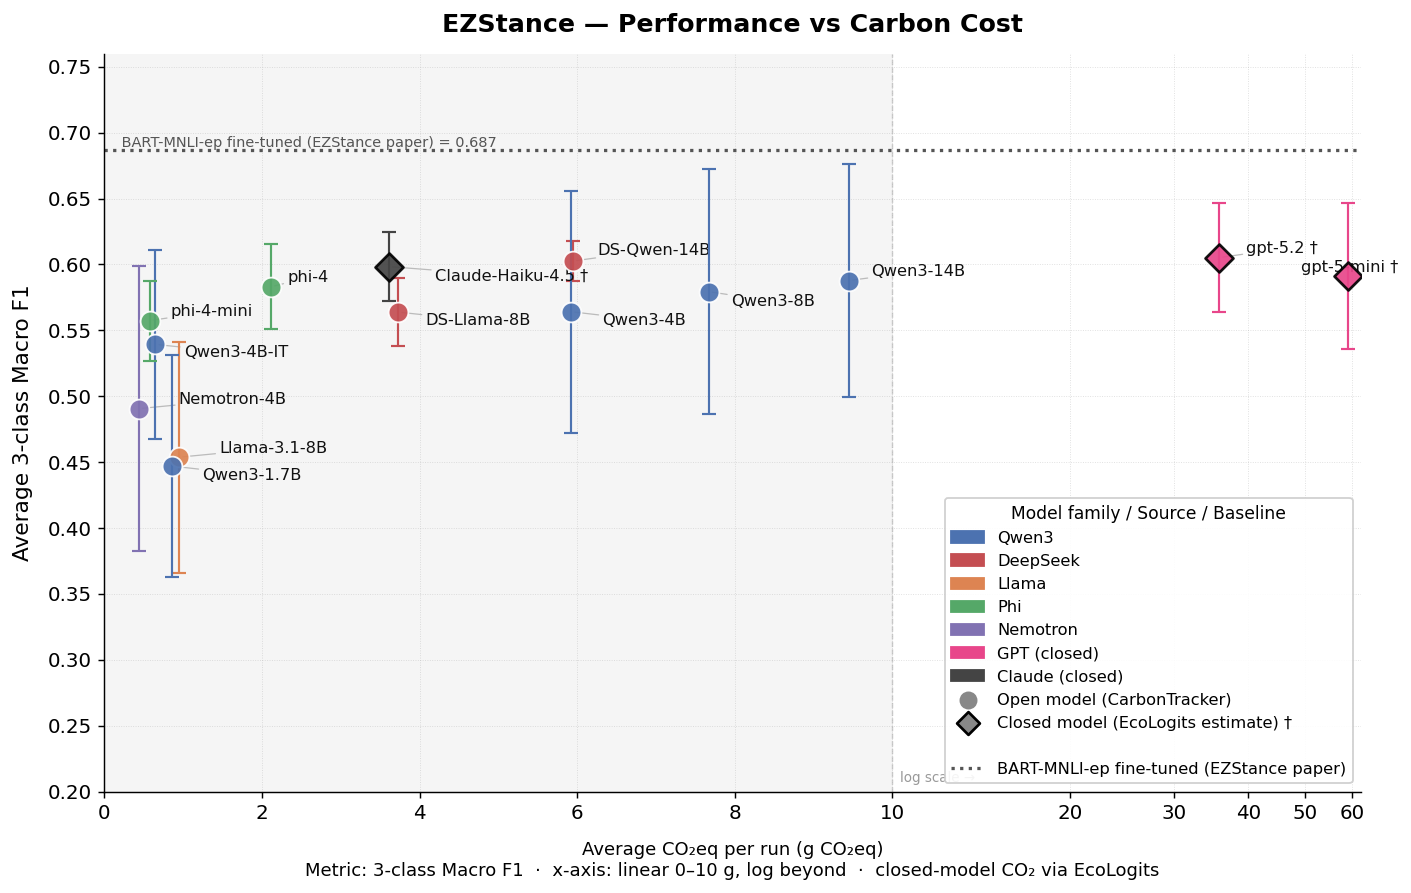

In [8]:
# ── EZStance ──────────────────────────────────────────────────────────────────
fig, ax = plot_co2_vs_f1('EZStance')
plt.show()

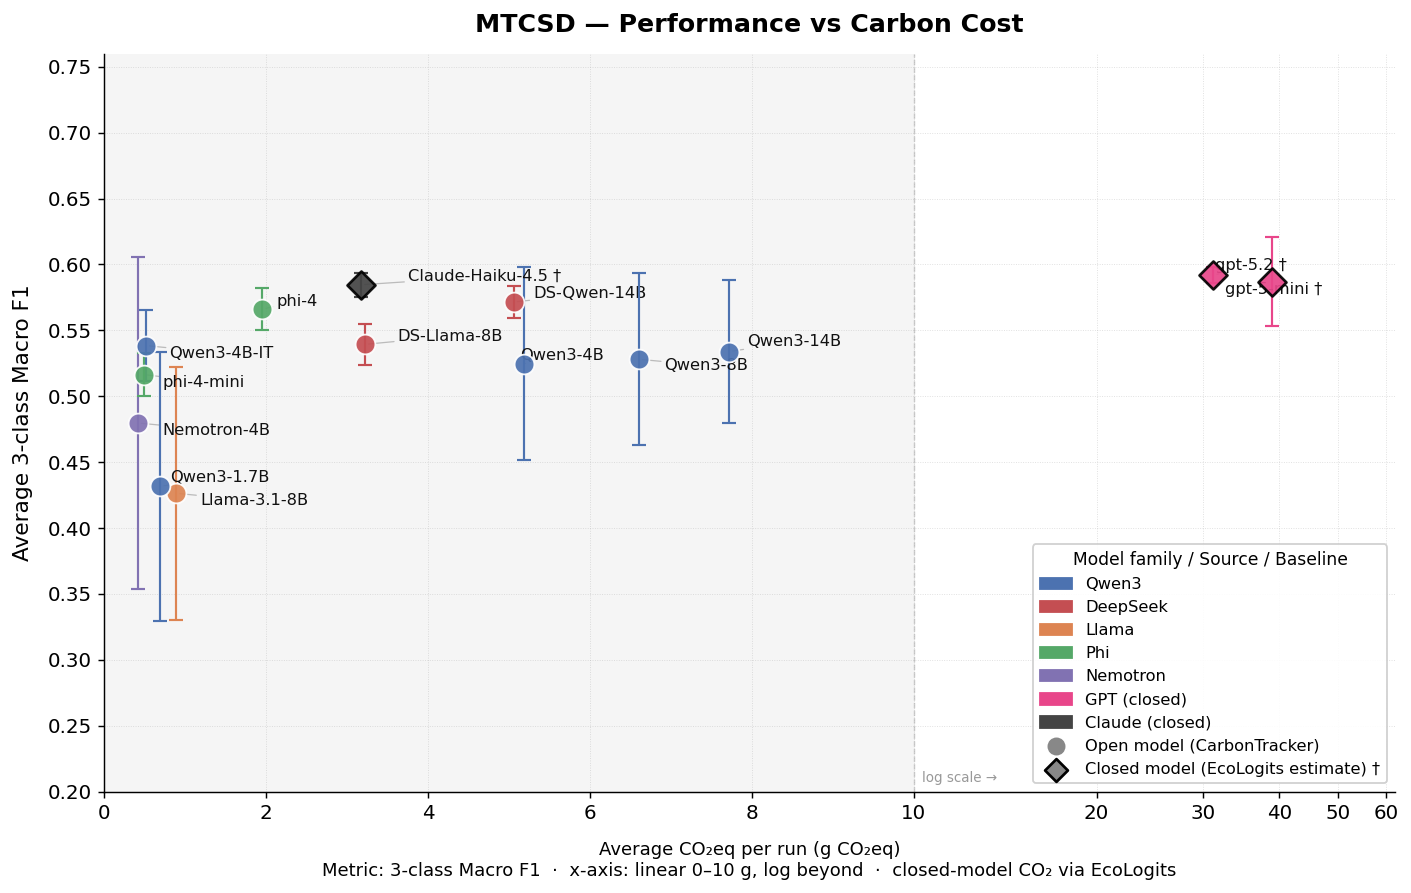

In [9]:
# ── MTCSD ─────────────────────────────────────────────────────────────────────
fig, ax = plot_co2_vs_f1('MTCSD')
plt.show()

### Average Performance Only (no error bars)

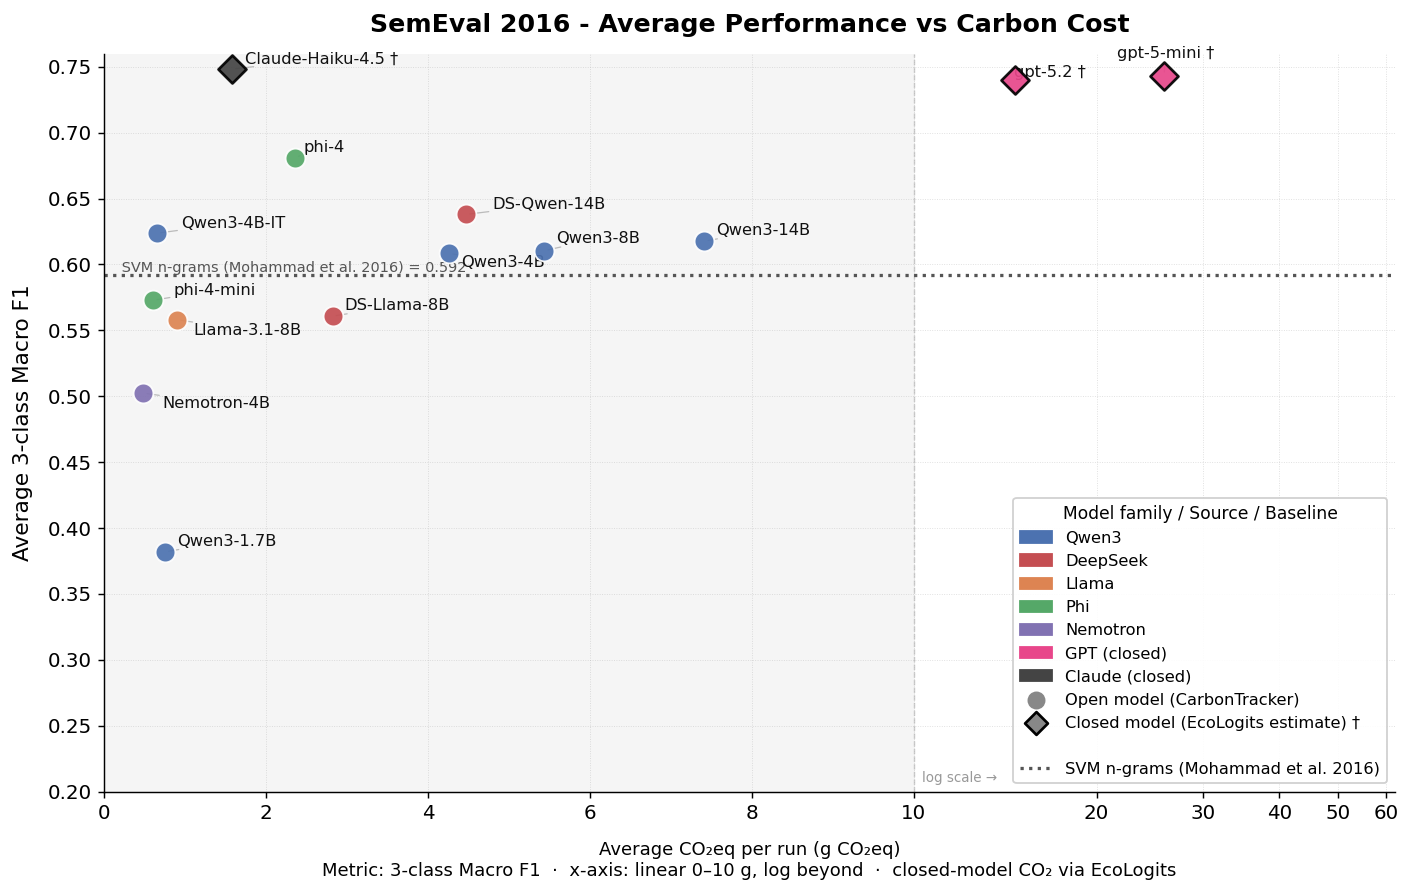

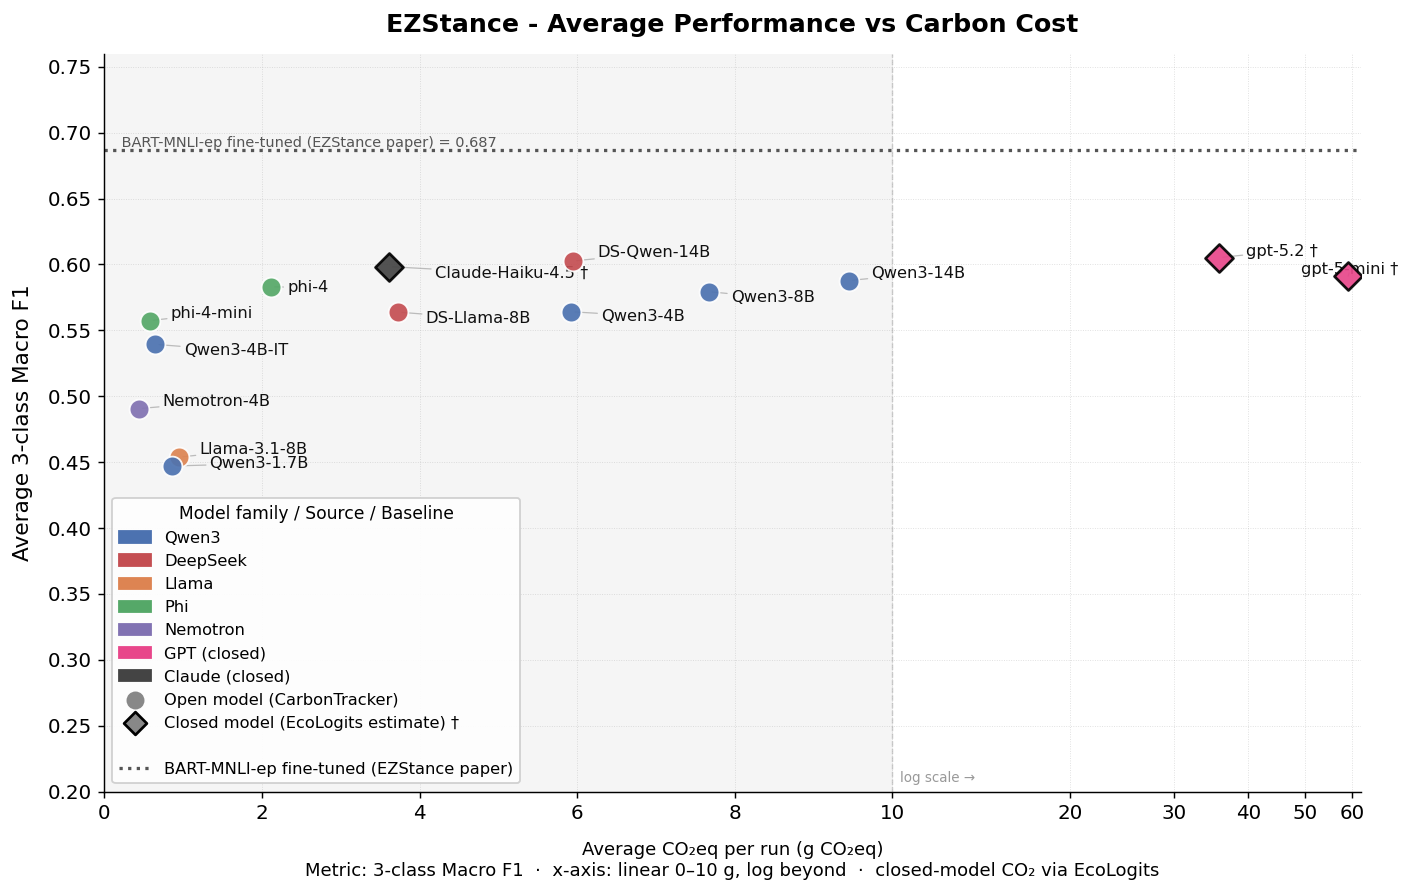

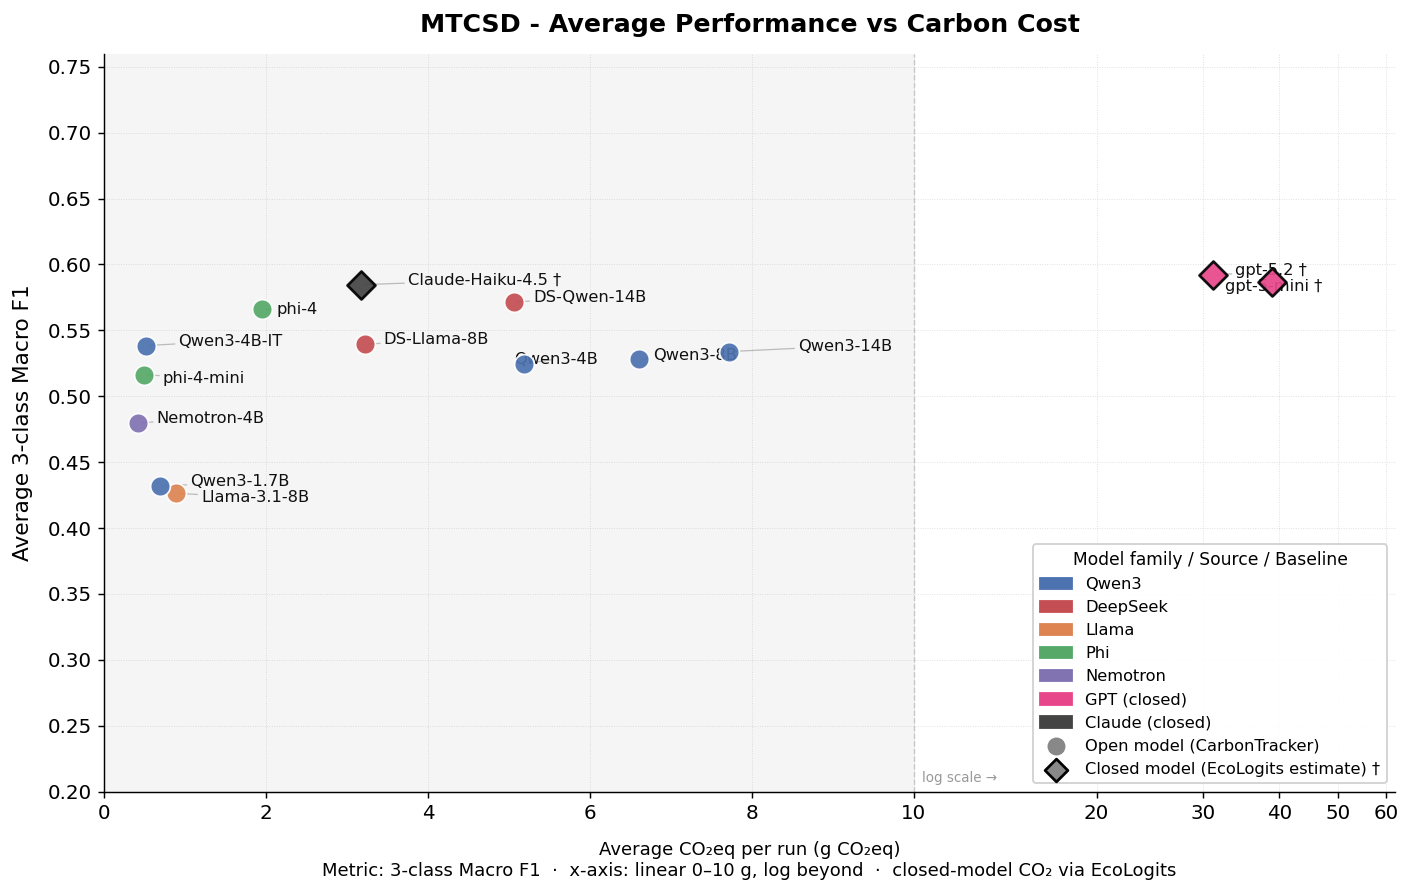

In [10]:
for ds in ['SemEval 2016', 'EZStance', 'MTCSD']:
    fig, ax = plot_co2_vs_f1(ds, error_bars=False)
    ax.set_title(f'{ds} - Average Performance vs Carbon Cost',
                 fontsize=14, fontweight='bold', pad=12)
    plt.show()

## 7. Combined Figure — All Three Datasets Side by Side

One wide figure with all three datasets as panels.  
Same axis scales, baselines, and colors as above.  
Single shared legend below the panels.

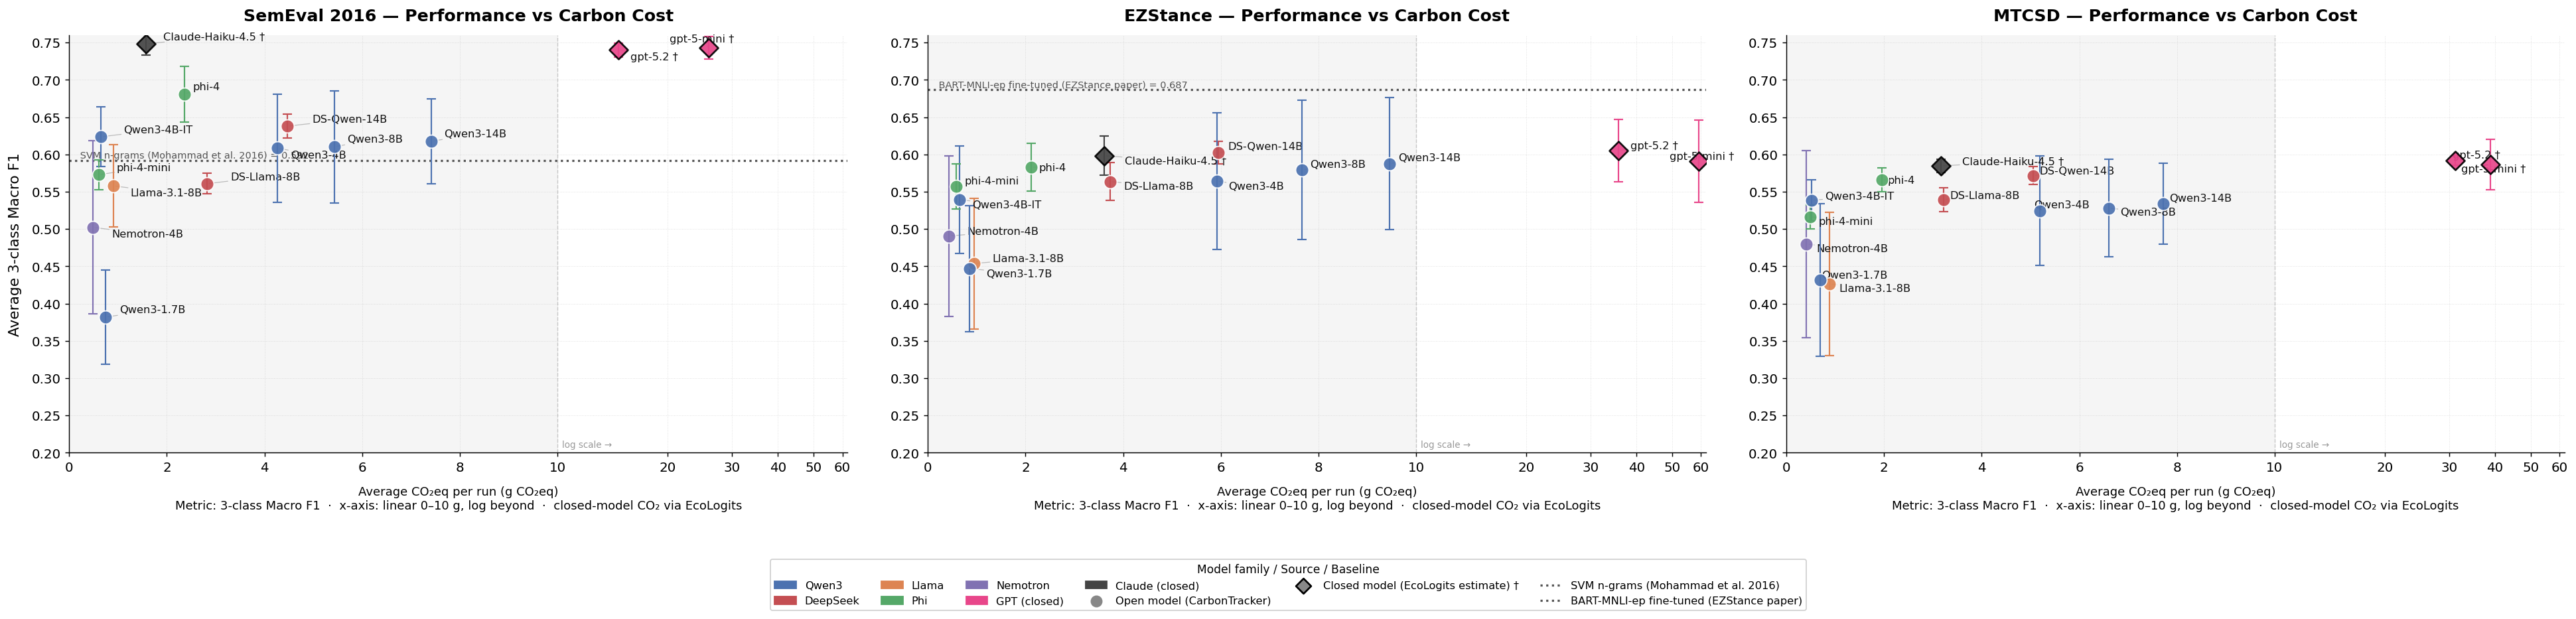

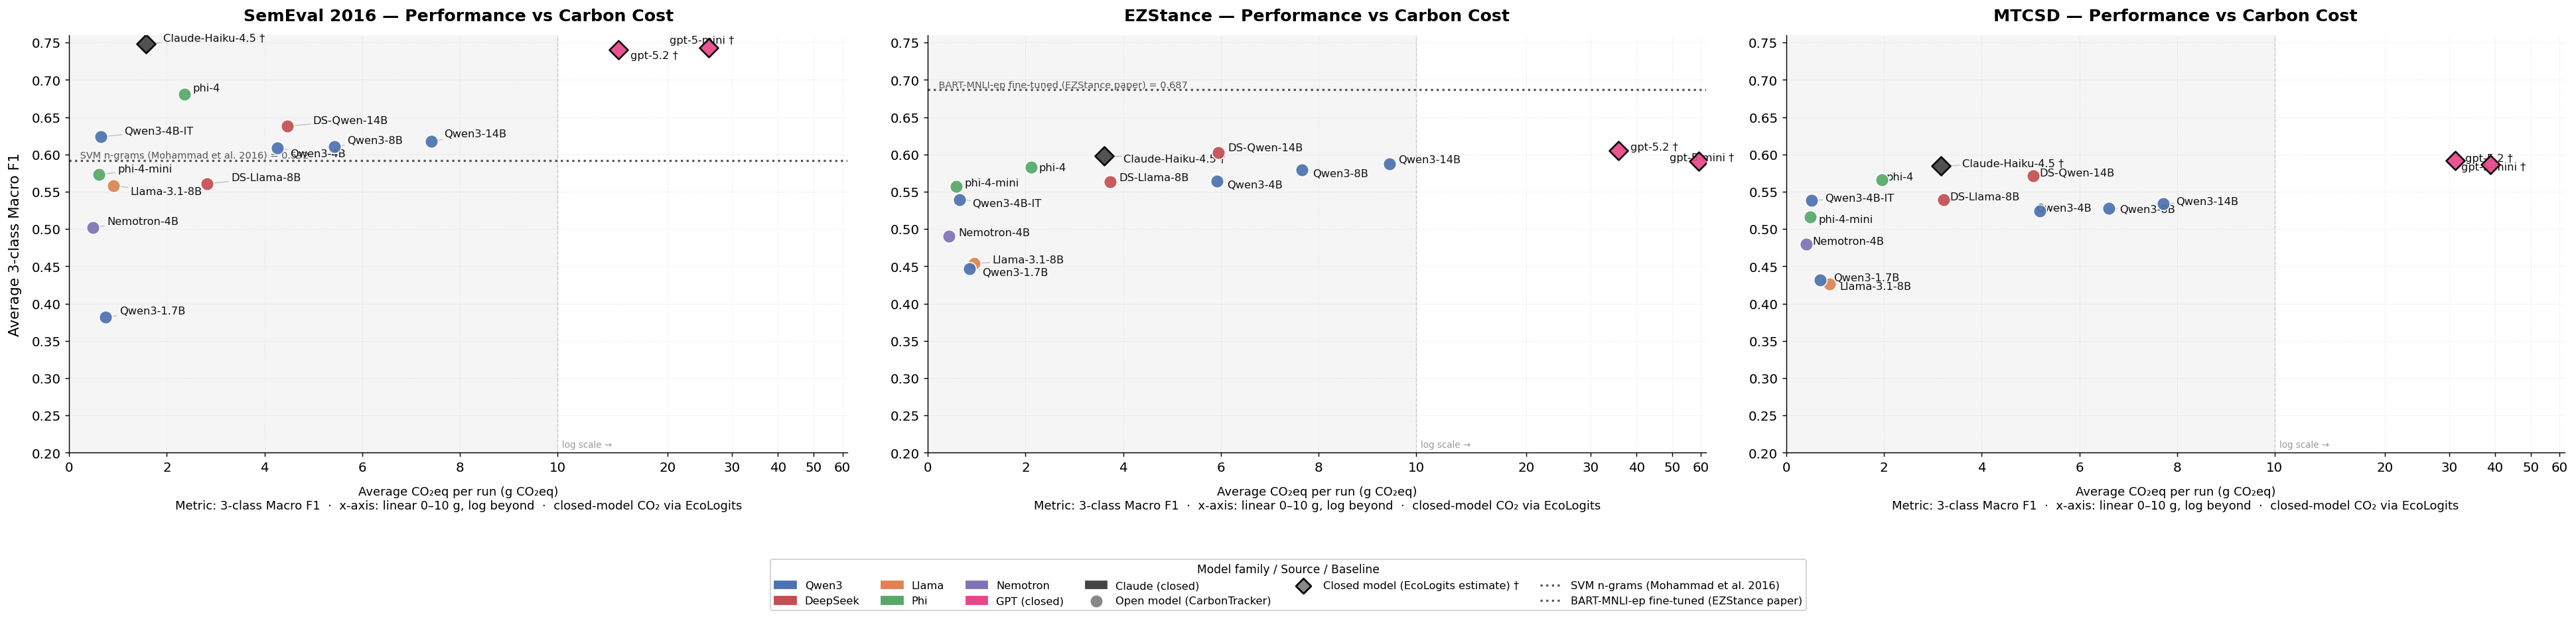

In [11]:
def plot_combined(stats_df=None, suptitle=None, save_path=None, error_bars=True):
    """
    All three datasets in one wide figure (1 row × 3 panels).
    error_bars: if True, draw ±1 std bars; if False, show only the average point.
    Same axis scales and styling as the individual plots.
    Single shared legend sits below all panels.
    """
    if stats_df is None:
        stats_df = model_stats

    DATASETS = ['SemEval 2016', 'EZStance', 'MTCSD']
    fig, axes = plt.subplots(1, 3, figsize=(30, 7))

    for i, (ds, ax) in enumerate(zip(DATASETS, axes)):
        plot_co2_vs_f1(ds, ax=ax, stats_df=stats_df, error_bars=error_bars)
        # Drop per-panel legend — we'll build one shared one below
        leg = ax.get_legend()
        if leg:
            leg.remove()
        # Y-label only on leftmost panel to avoid repetition
        if i > 0:
            ax.set_ylabel('')

    # ── Shared legend ──────────────────────────────────────────────────────────
    all_families = stats_df['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in all_families
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (CarbonTracker)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (EcoLogits estimate) †'),
    ]
    # Collect unique baselines across all three datasets
    baseline_handles, seen = [], set()
    for ds in DATASETS:
        for label, value in SUPERVISED_BASELINES.get(ds, []):
            if label not in seen:
                baseline_handles.append(
                    plt.Line2D([0], [0], linestyle=':', color='#555', linewidth=1.8, label=label)
                )
                seen.add(label)

    all_handles = family_handles + marker_handles
    if baseline_handles:
        all_handles += [mpatches.Patch(color='none', label='')] + baseline_handles

    fig.legend(
        handles=all_handles, fontsize=9,
        title='Model family / Source / Baseline', title_fontsize=9.5,
        loc='lower center', ncol=min(len(all_handles), 6),
        bbox_to_anchor=(0.5, -0.03), framealpha=0.9,
    )

    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight='bold', y=1.01)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)  # room for the shared legend

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')
    return fig, axes


# ── With error bars ───────────────────────────────────────────────────────────
fig, axes = plot_combined(error_bars=True)
plt.show()

# ── Without error bars (average only) ────────────────────────────────────────
fig, axes = plot_combined(error_bars=False)
plt.show()

## 7. Save Figures to PDF

Run this cell to save publication-quality versions.

---
## 8. Task 2 — Throughput vs Performance

X-axis: average throughput (tokens/sec) — log scale because open models span 100s to 100,000s tok/s.  
Y-axis: average 3-class Macro F1.  
One point per model per dataset, average only (no error bars).  
Open model throughput = GPU tokens/sec from vllm; closed model = total tokens / runtime via API.

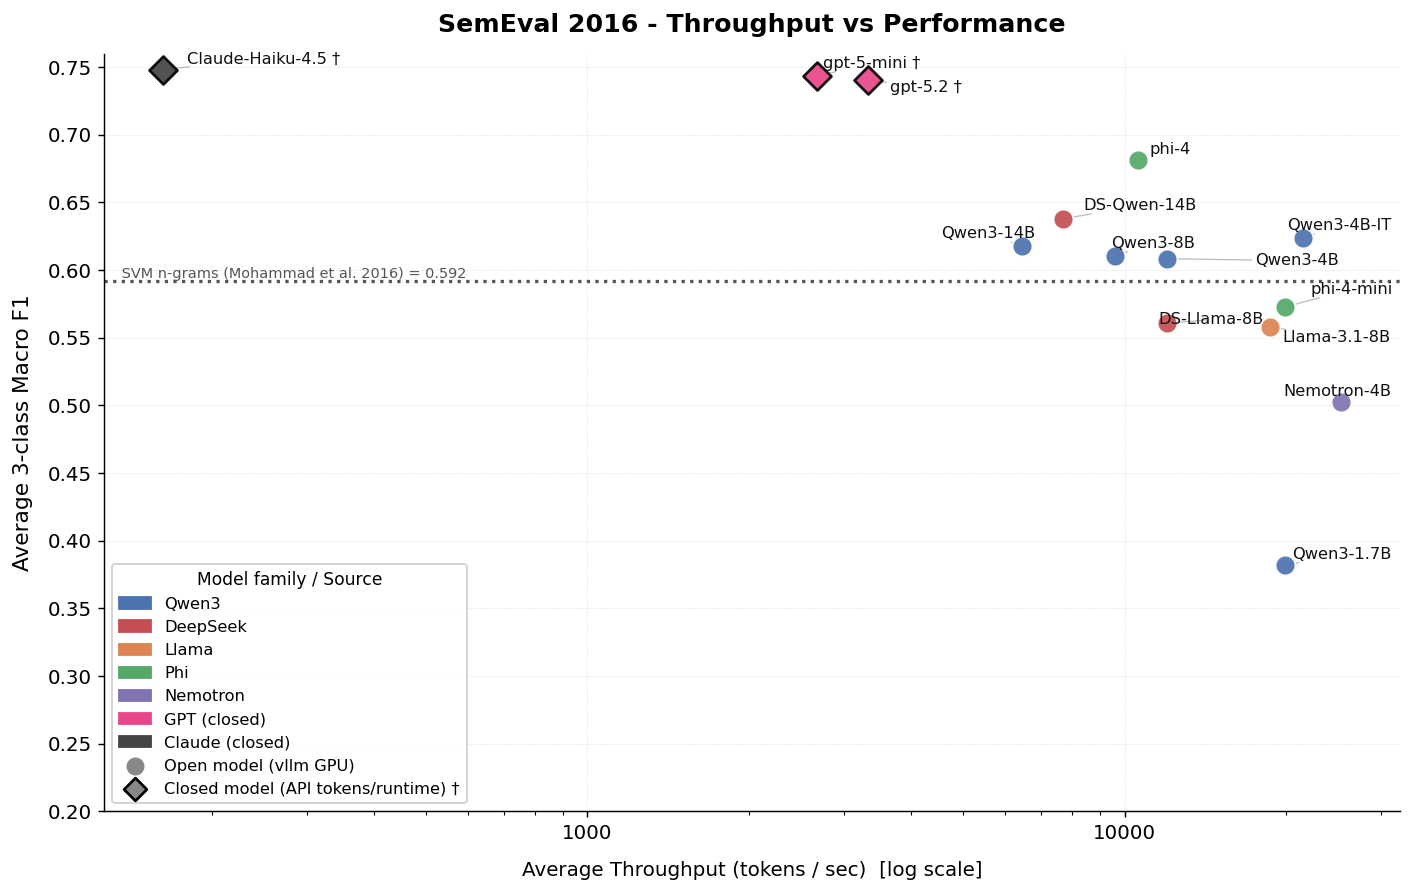

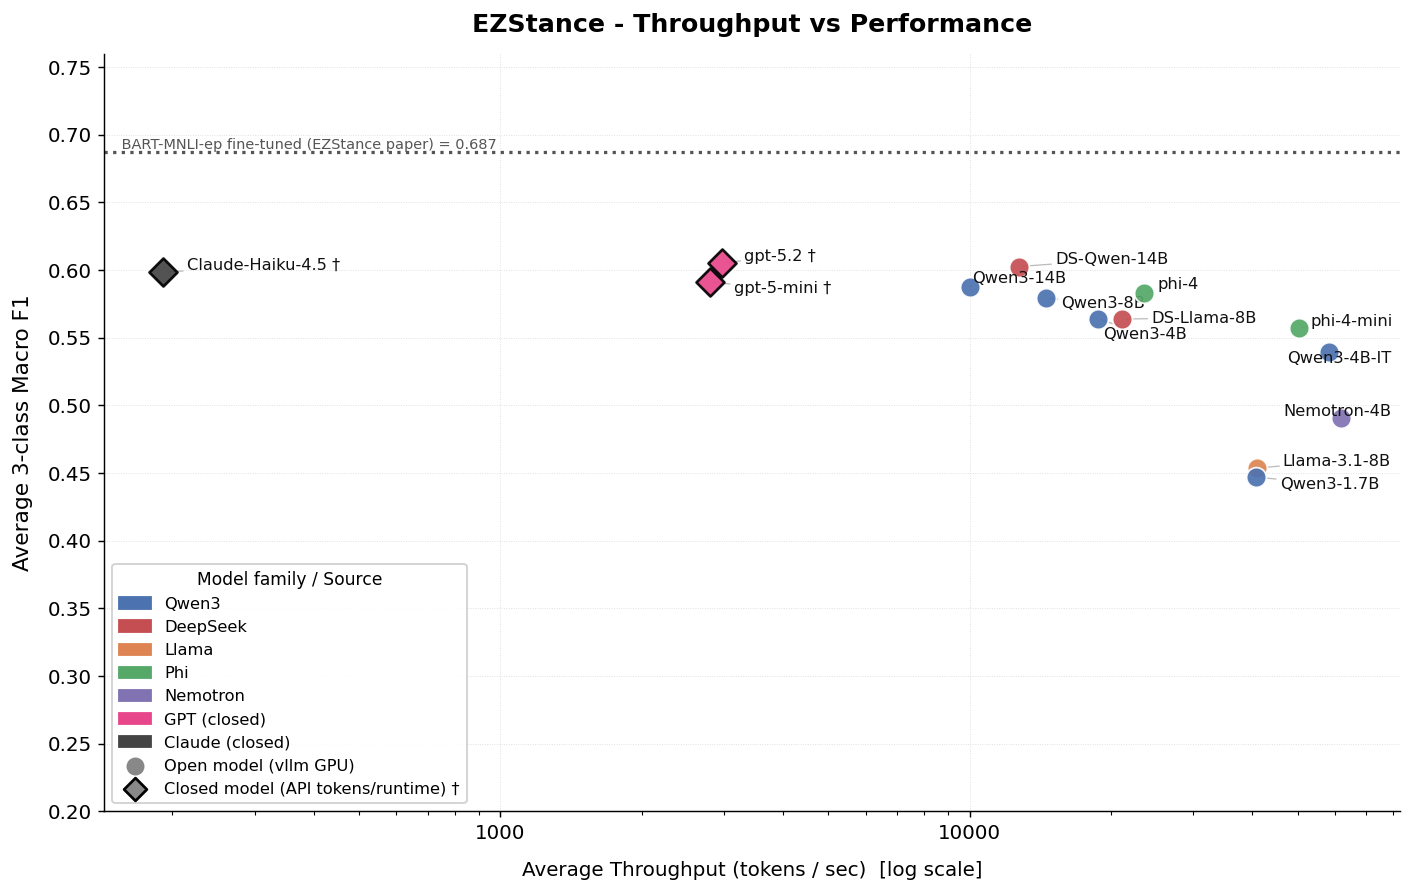

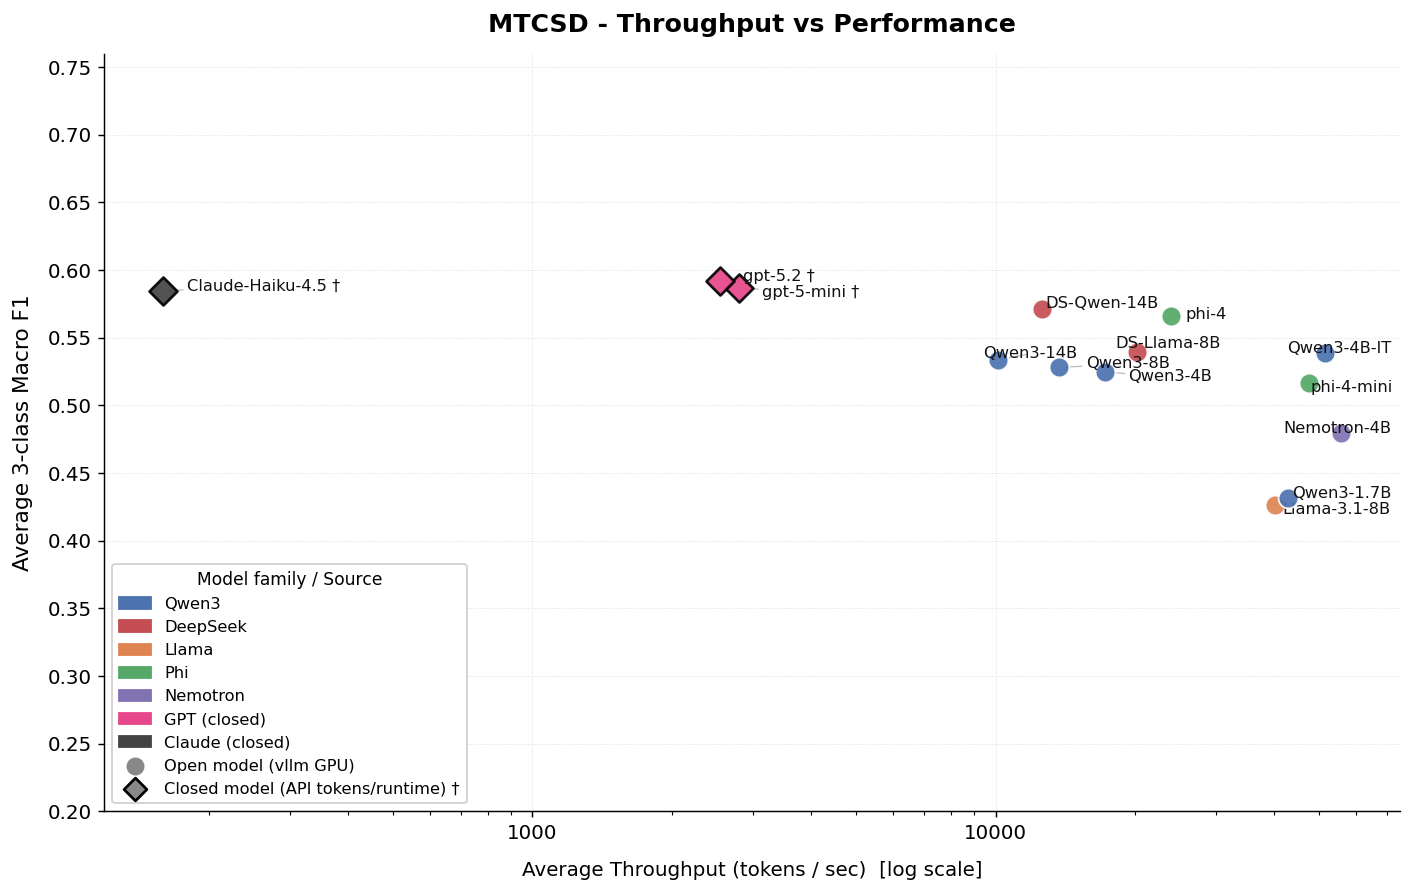

In [12]:
def plot_throughput_vs_f1(dataset_name, ax=None, save_path=None, stats_df=None):
    """
    Scatter: x = avg throughput (tok/s, log scale), y = avg macro-F1.
    Average only — no error bars. One point per model.
    """
    if stats_df is None:
        stats_df = model_stats

    subset = stats_df[
        (stats_df['dataset'] == dataset_name) &
        stats_df['avg_throughput'].notna()
    ].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 7))
    else:
        fig = ax.get_figure()

    ax.set_xscale('log')

    # ── Supervised baseline lines ─────────────────────────────────────────────
    for label, value in SUPERVISED_BASELINES.get(dataset_name, []):
        ax.axhline(value, linestyle=':', linewidth=1.8, color='#555', zorder=1)
        ax.text(0.01, value, f' {label} = {value:.3f}',
                transform=ax.get_yaxis_transform(),
                fontsize=8, color='#555', va='bottom')

    # ── Scatter points ────────────────────────────────────────────────────────
    texts = []
    for _, row in subset.iterrows():
        marker    = 'D' if not row['is_open'] else 'o'
        edgecolor = 'black' if not row['is_open'] else 'white'
        linewidth = 1.5 if not row['is_open'] else 1.0

        ax.scatter(row['avg_throughput'], row['avg_f1'],
                   s=120, color=row['color'], marker=marker,
                   edgecolors=edgecolor, linewidths=linewidth,
                   alpha=0.92, zorder=3)
        texts.append(ax.text(row['avg_throughput'], row['avg_f1'],
                             row['label'], fontsize=9, color='#111'))

    adjust_text(texts, ax=ax, expand=(1.4, 1.8),
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7))

    # ── Axes ──────────────────────────────────────────────────────────────────
    ax.set_ylim(GLOBAL_YMIN, GLOBAL_YMAX)
    ax.set_yticks(GLOBAL_YTICKS)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='x')

    ax.set_ylabel('Average 3-class Macro F1', fontsize=12, labelpad=8)
    ax.set_xlabel('Average Throughput (tokens / sec)  [log scale]', fontsize=11, labelpad=10)
    ax.set_title(f'{dataset_name} - Throughput vs Performance',
                 fontsize=14, fontweight='bold', pad=12)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.4, color='#aaa')
    ax.spines[['top', 'right']].set_visible(False)

    # ── Legend ────────────────────────────────────────────────────────────────
    families_present = subset['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in families_present
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (vllm GPU)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (API tokens/runtime) †'),
    ]
    ax.legend(handles=family_handles + marker_handles, fontsize=9,
              title='Model family / Source', title_fontsize=9.5,
              loc='best', framealpha=0.9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')
    return fig, ax


for ds in ['SemEval 2016', 'EZStance', 'MTCSD']:
    fig, ax = plot_throughput_vs_f1(ds)
    plt.show()

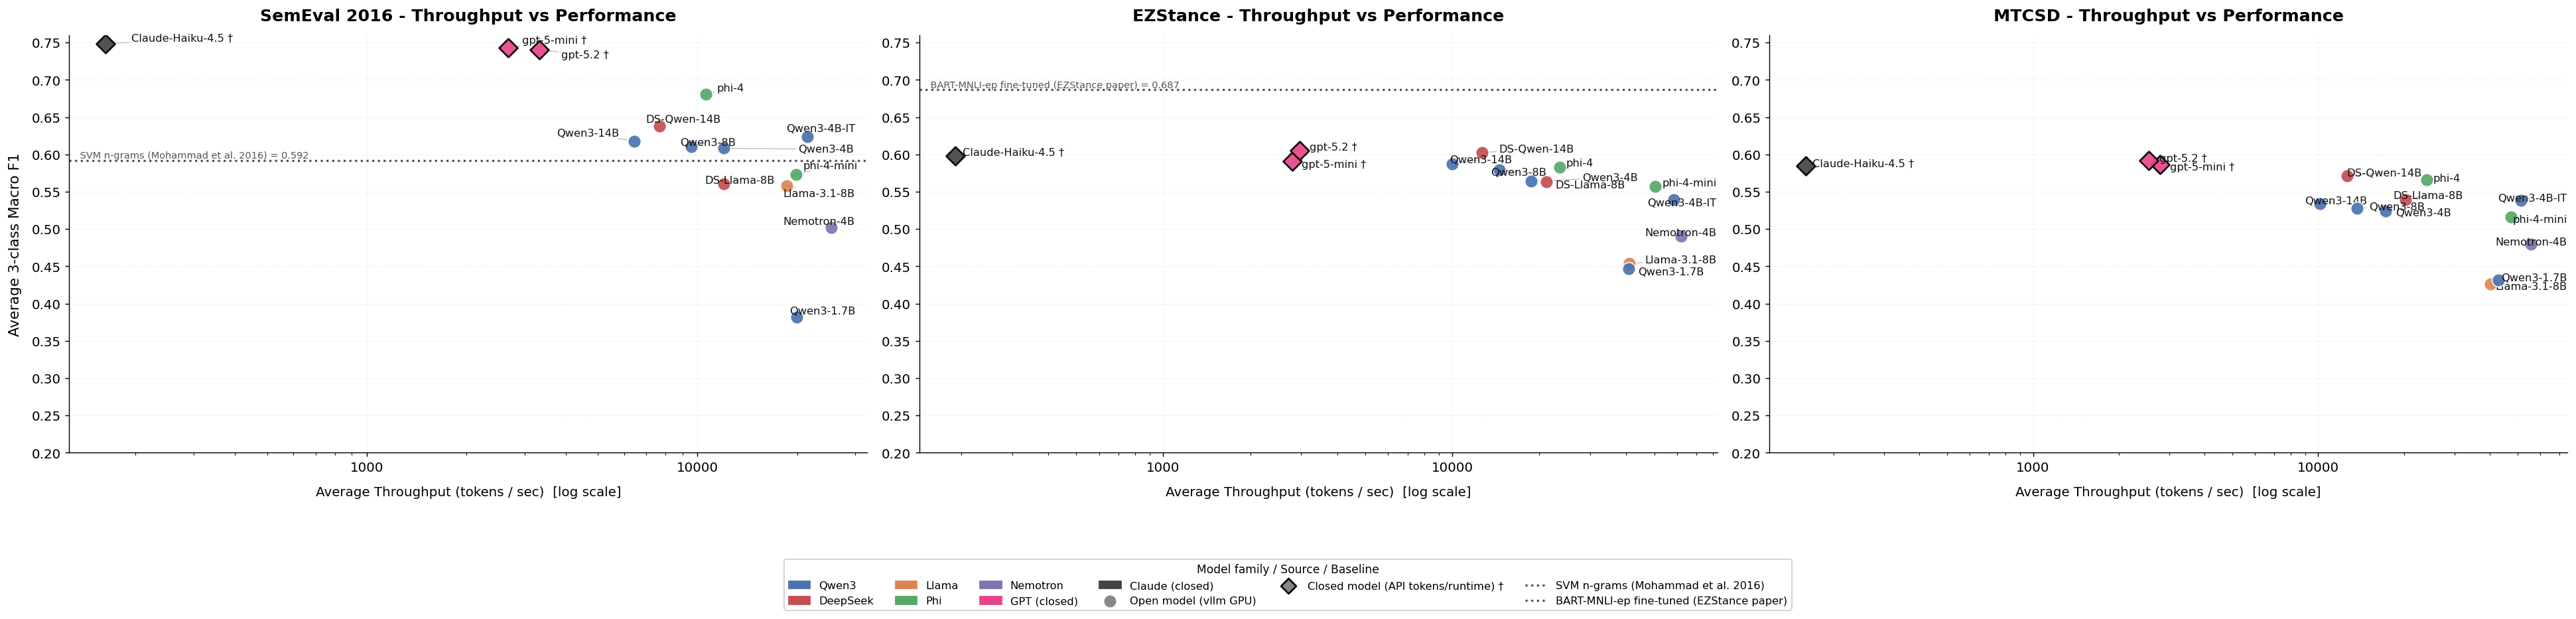

In [13]:
# ── Combined throughput figure — all three datasets side by side ──────────────
def plot_throughput_combined(stats_df=None, save_path=None):
    if stats_df is None:
        stats_df = model_stats

    DATASETS = ['SemEval 2016', 'EZStance', 'MTCSD']
    fig, axes = plt.subplots(1, 3, figsize=(30, 7))

    for i, (ds, ax) in enumerate(zip(DATASETS, axes)):
        plot_throughput_vs_f1(ds, ax=ax, stats_df=stats_df)
        leg = ax.get_legend()
        if leg:
            leg.remove()
        if i > 0:
            ax.set_ylabel('')

    # Shared legend
    all_families = stats_df['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in all_families
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (vllm GPU)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (API tokens/runtime) †'),
    ]
    baseline_handles, seen = [], set()
    for ds in DATASETS:
        for label, value in SUPERVISED_BASELINES.get(ds, []):
            if label not in seen:
                baseline_handles.append(
                    plt.Line2D([0], [0], linestyle=':', color='#555', linewidth=1.8, label=label)
                )
                seen.add(label)

    all_handles = family_handles + marker_handles
    if baseline_handles:
        all_handles += [mpatches.Patch(color='none', label='')] + baseline_handles

    fig.legend(handles=all_handles, fontsize=9,
               title='Model family / Source / Baseline', title_fontsize=9.5,
               loc='lower center', ncol=min(len(all_handles), 6),
               bbox_to_anchor=(0.5, -0.03), framealpha=0.9)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.24)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')
    return fig, axes


fig, axes = plot_throughput_combined()
plt.show()

In [14]:
OUT_DIR = '/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper'

# ── CO2 vs F1 — individual, with error bars ───────────────────────────────────
for ds, tag in [('SemEval 2016','semeval'), ('EZStance','ezstance'), ('MTCSD','mtcsd')]:
    plot_co2_vs_f1(ds, save_path=f'{OUT_DIR}/task1_co2_f1_{tag}.pdf')
    plt.close()

# ── CO2 vs F1 — individual, average only ─────────────────────────────────────
for ds, tag in [('SemEval 2016','semeval'), ('EZStance','ezstance'), ('MTCSD','mtcsd')]:
    fig, ax = plot_co2_vs_f1(ds, error_bars=False)
    ax.set_title(f'{ds} — Average Performance vs Carbon Cost', fontsize=14, fontweight='bold', pad=12)
    plt.savefig(f'{OUT_DIR}/task1_co2_f1_{tag}_clean.pdf', bbox_inches='tight')
    plt.close()

# ── CO2 vs F1 — combined, with error bars ────────────────────────────────────
plot_combined(error_bars=True,  save_path=f'{OUT_DIR}/task1_co2_f1_combined.pdf')
plt.close()

# ── CO2 vs F1 — combined, average only ───────────────────────────────────────
plot_combined(error_bars=False, save_path=f'{OUT_DIR}/task1_co2_f1_combined_clean.pdf')
plt.close()

# ── Throughput vs F1 — individual ────────────────────────────────────────────
for ds, tag in [('SemEval 2016','semeval'), ('EZStance','ezstance'), ('MTCSD','mtcsd')]:
    plot_throughput_vs_f1(ds, save_path=f'{OUT_DIR}/task2_throughput_f1_{tag}.pdf')
    plt.close()

# ── Throughput vs F1 — combined ──────────────────────────────────────────────
plot_throughput_combined(save_path=f'{OUT_DIR}/task2_throughput_f1_combined.pdf')
plt.close()

print('All 10 figures saved.')

Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task1_co2_f1_semeval.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task1_co2_f1_ezstance.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task1_co2_f1_mtcsd.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task1_co2_f1_combined.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task1_co2_f1_combined_clean.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task2_throughput_f1_semeval.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task2_throughput_f1_ezstance.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task2_throughput_f1_mtcsd.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/task2_throughput_f1_combined.pdf
All 10 figures saved.


---
## 9. MTCSD — 2-Class F_avg (Favor + Against Only)

The MT²-CSD paper evaluates using **F_avg = (F_favor + F_against) / 2**, excluding the NONE class.  
We replicate that metric here so our results are directly comparable to Table IX of the paper.

Our test set excludes Post-T, so the baseline is re-averaged over the 5 remaining targets  
(Bitcoin, Tesla, SpaceX, Biden, Trump) from the "Only considering individual posts/comments" section.  
We use **KPT** as the single best baseline in this category:

KPT F_avg per target: Bitcoin=50.34, Tesla=43.11, SpaceX=47.47, Biden=28.90, Trump=41.87 → **avg = 42.34**

In [15]:
# ── F_avg helper (NONE excluded) ──────────────────────────────────────────────
def compute_favg(assignments_csv_path):
    df = pd.read_csv(assignments_csv_path)
    if 'run' in df.columns:
        df = df[df['run'] == 0]
    df['true'] = df['original_stance'].apply(normalize_label)
    df['pred'] = df['predicted_stance'].apply(normalize_label)
    valid = df[df['true'].notna() & df['pred'].notna()]
    if len(valid) < 10:
        return None
    f_favor   = f1_score(valid['true'], valid['pred'], labels=['FAVOR'],   average='macro', zero_division=0)
    f_against = f1_score(valid['true'], valid['pred'], labels=['AGAINST'], average='macro', zero_division=0)
    return float((f_favor + f_against) / 2)


def load_all_runs_favg(dataset_dir, dataset_name):
    """Like load_all_runs but uses F_avg instead of 3-class macro F1."""
    rows = []
    for folder_name in sorted(os.listdir(dataset_dir)):
        folder_path      = os.path.join(dataset_dir, folder_name)
        summary_path     = os.path.join(folder_path, 'summary.json')
        assignments_path = os.path.join(folder_path, 'document_assignments.csv')
        if not (os.path.isdir(folder_path)
                and os.path.exists(summary_path)
                and os.path.exists(assignments_path)):
            continue

        s    = json.load(open(summary_path))
        cfg  = s.get('configuration', {})
        runs = s.get('runs', [])
        if not runs:
            continue
        run0 = runs[0]

        backend = cfg.get('llm_backend', '')
        if backend == 'vllm':
            model, is_open = cfg.get('vllm_model', '').split('/')[-1], True
        elif backend == 'openai':
            model, is_open = cfg.get('openai_model', ''), False
        elif backend == 'claude':
            model, is_open = cfg.get('claude_model', ''), False
        else:
            continue

        prompt = cfg.get('stance_prompt_name', 'unknown')

        try:
            favg = compute_favg(assignments_path)
        except Exception:
            favg = None
        if favg is None:
            continue

        if is_open:
            co2_g      = lookup_carbon(dataset_name, model, prompt)
            throughput = lookup_throughput(dataset_name, model, prompt)
            num_ex     = run0.get('num_examples')
            runtime    = run0.get('runtime_seconds')
            docs_ps    = (num_ex / runtime) if (num_ex and runtime) else None
        else:
            co2_g      = get_carbon_grams_closed(summary_path)
            throughput = run0.get('throughput_tokens_per_sec')
            num_ex     = run0.get('num_examples')
            runtime    = run0.get('runtime_seconds')
            docs_ps    = (num_ex / runtime) if (num_ex and runtime) else None

        rows.append({
            'dataset': dataset_name, 'model': model, 'prompt': prompt,
            'favg': favg, 'co2_g': co2_g, 'is_open': is_open,
            'throughput_tok_s': throughput, 'docs_per_sec': docs_ps,
        })

    print(f'  {dataset_name}: {len(rows)} valid runs (F_avg)')
    return pd.DataFrame(rows)


# Load MTCSD results using F_avg
print('Loading MTCSD runs with F_avg metric...')
mtcsd_favg_frames = []
for d in DATASET_DIRS['MTCSD']:
    if os.path.isdir(d):
        mtcsd_favg_frames.append(load_all_runs_favg(d, 'MTCSD'))
mtcsd_favg_runs = pd.concat(mtcsd_favg_frames, ignore_index=True)

# Aggregate: one point per model
mtcsd_favg_runs_clean = mtcsd_favg_runs[
    mtcsd_favg_runs['favg'].notna() & mtcsd_favg_runs['co2_g'].notna()
].copy()

mtcsd_favg_stats = (
    mtcsd_favg_runs_clean
    .groupby(['model', 'is_open'])
    .agg(
        n_prompts        = ('favg',           'count'),
        avg_favg         = ('favg',           'mean'),
        std_favg         = ('favg',           'std'),
        avg_co2_g        = ('co2_g',          'mean'),
        avg_throughput   = ('throughput_tok_s', 'mean'),
    )
    .reset_index()
)
mtcsd_favg_stats['label']  = mtcsd_favg_stats['model'].map(MODEL_LABELS).fillna(mtcsd_favg_stats['model'])
mtcsd_favg_stats['family'] = mtcsd_favg_stats['model'].map(MODEL_FAMILY).fillna('Other')
mtcsd_favg_stats['color']  = mtcsd_favg_stats['family'].map(FAMILY_COLORS).fillna('#888')
mtcsd_favg_stats['std_favg'] = mtcsd_favg_stats['std_favg'].fillna(0)

print(f'\nModels with F_avg: {len(mtcsd_favg_stats)}')
display(
    mtcsd_favg_stats[['model', 'family', 'n_prompts', 'avg_favg', 'std_favg', 'avg_co2_g']]
    .sort_values('avg_favg', ascending=False)
    .reset_index(drop=True)
    .style.format({'avg_favg': '{:.3f}', 'std_favg': '{:.3f}', 'avg_co2_g': '{:.2f}'})
)

Loading MTCSD runs with F_avg metric...
  MTCSD: 142 valid runs (F_avg)
  MTCSD: 11 valid runs (F_avg)

Models with F_avg: 14


,model,family,n_prompts,avg_favg,std_favg,avg_co2_g
0,claude-haiku-4-5-20251001,Claude (closed),11,0.556,0.017,3.17
1,gpt-5-mini,GPT (closed),10,0.551,0.025,38.84
2,gpt-5.2,GPT (closed),11,0.544,0.008,31.16
3,DeepSeek-R1-Distill-Qwen-14B,DeepSeek,11,0.518,0.013,5.06
4,phi-4,Phi,11,0.518,0.018,1.95
5,phi-4-mini-instruct,Phi,11,0.498,0.008,0.49
6,Qwen3-4B-Instruct-2507,Qwen3,11,0.487,0.046,0.51
7,DeepSeek-R1-Distill-Llama-8B,DeepSeek,11,0.482,0.016,3.22
8,Qwen3-4B,Qwen3,11,0.478,0.065,5.18
9,Nemotron-Mini-4B-Instruct,Nemotron,11,0.467,0.102,0.41


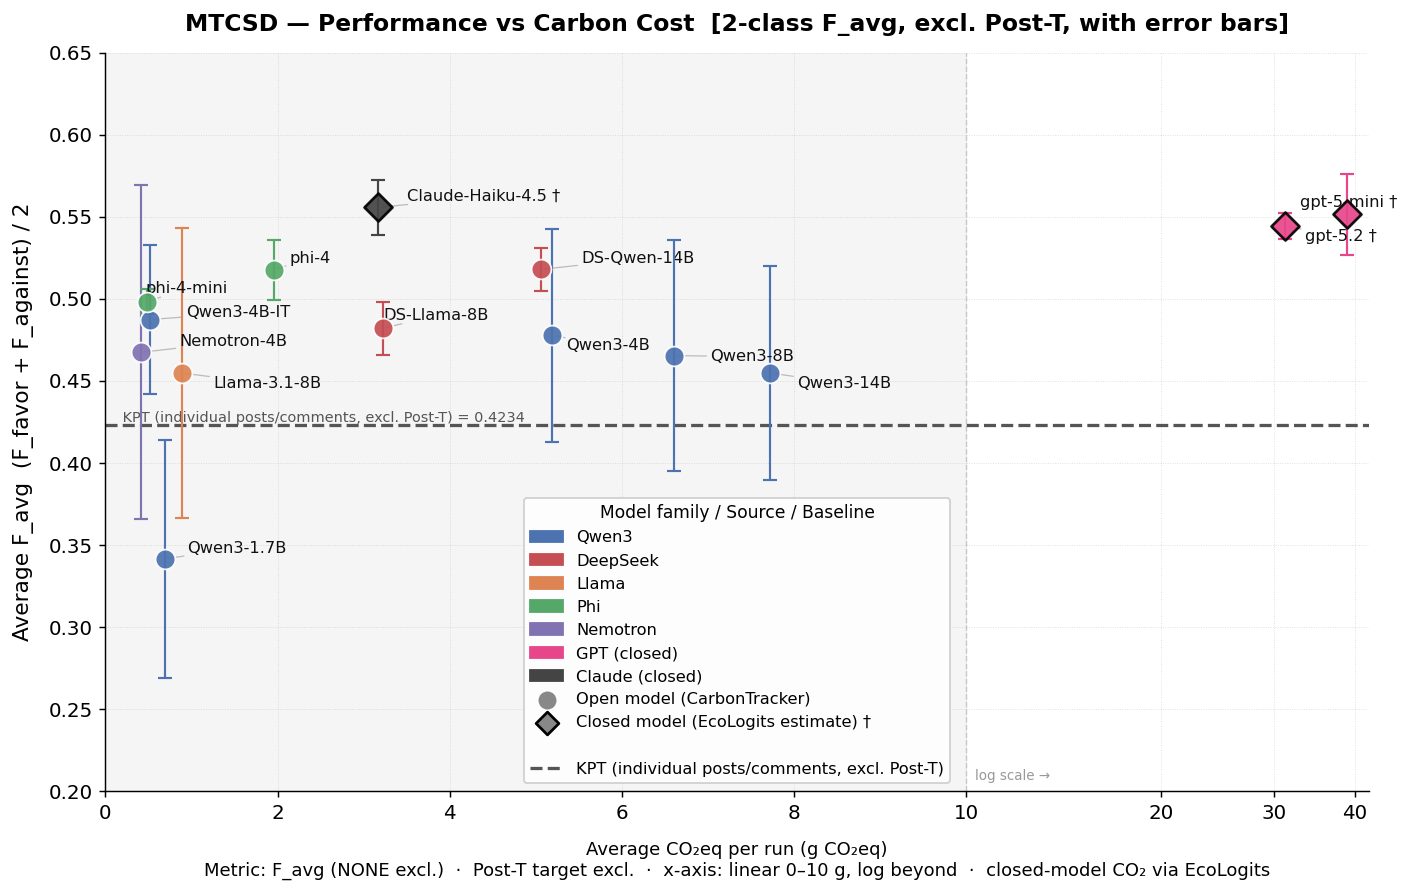

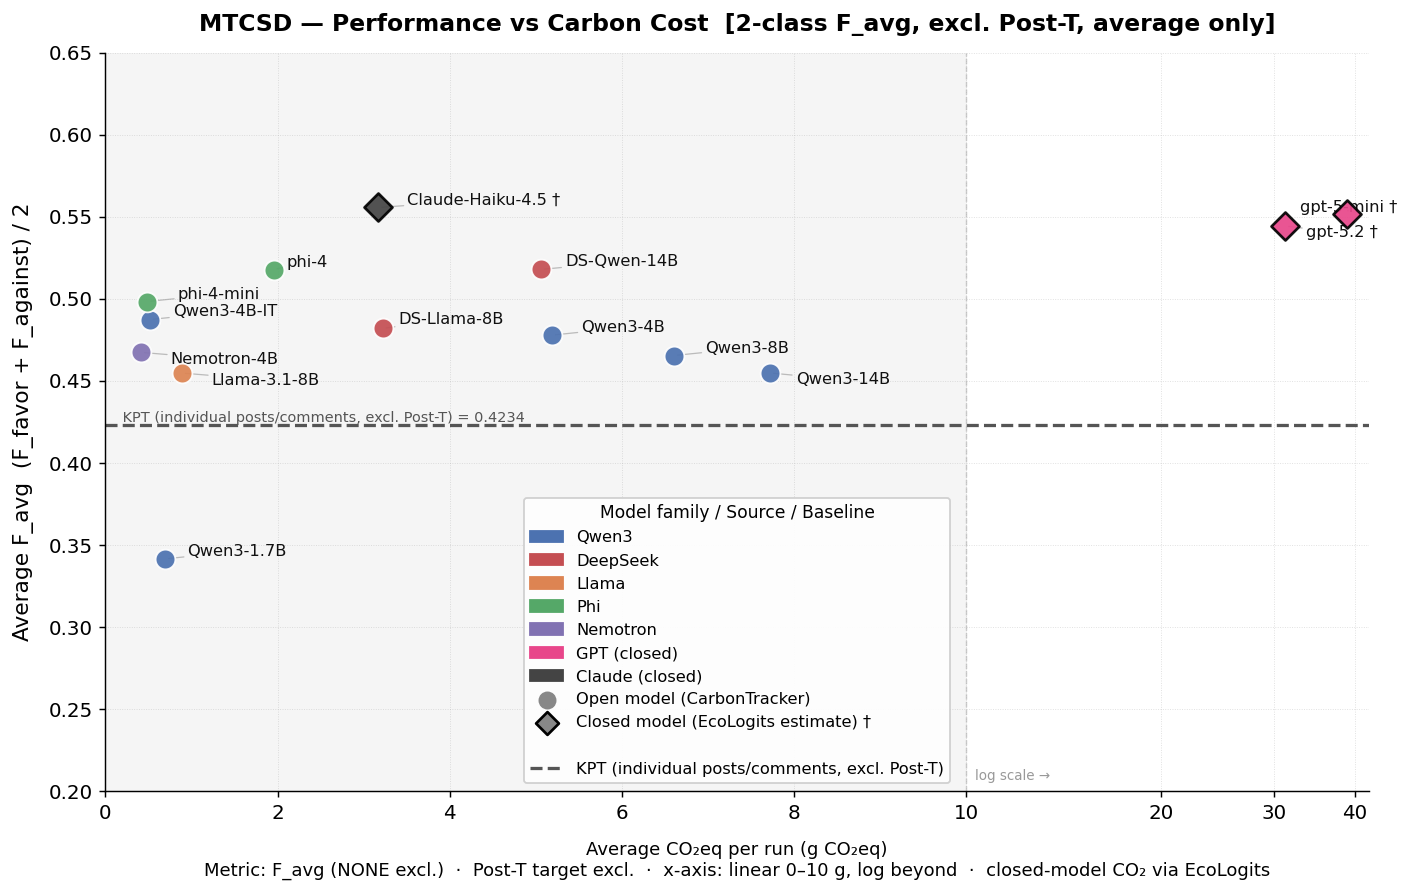

In [16]:
# ── Paper baselines (Table IX, MT2-CSD paper) ─────────────────────────────────
# F_avg = (F_favor + F_against) / 2
# Best individual-posts baseline: KPT, re-averaged over 5 targets (excl. Post-T)
# KPT: (50.34+43.11+47.47+28.90+41.87)/5 = 42.34
MTCSD_BASELINES_FAVG = [
    ('KPT (individual posts/comments, excl. Post-T)', 0.4234, '#555555', '--'),
]

FAVG_YMIN   = 0.20
FAVG_YMAX   = 0.65
FAVG_YTICKS = np.arange(0.20, FAVG_YMAX + 0.01, 0.05)

_co2_max_favg = mtcsd_favg_stats['avg_co2_g'].max()
FAVG_XMAX   = np.ceil(_co2_max_favg / 5) * 5 + 2


def _draw_favg_baselines(ax):
    """Draw MTCSD baseline hlines and return legend handles."""
    handles = []
    for label, value, color, ls in MTCSD_BASELINES_FAVG:
        ax.axhline(value, linestyle=ls, linewidth=1.8, color=color, zorder=2)
        ax.text(0.01, value, f' {label} = {value:.4f}',
                transform=ax.get_yaxis_transform(),
                fontsize=8, color=color, va='bottom')
        handles.append(plt.Line2D([0], [0], linestyle=ls, color=color,
                                  linewidth=1.8, label=label))
    return handles


def plot_mtcsd_favg_co2(stats_df=None, ax=None, save_path=None, error_bars=True):
    """CO2 vs F_avg scatter for MTCSD, matching paper's evaluation metric."""
    if stats_df is None:
        stats_df = mtcsd_favg_stats

    subset = stats_df[stats_df['avg_co2_g'].notna()].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 7))
    else:
        fig = ax.get_figure()

    ax.set_xscale('symlog', linthresh=SYMLOG_THRESH, linscale=1.2)
    ax.axvspan(0, SYMLOG_THRESH, color='#f5f5f5', zorder=0)
    ax.axvline(SYMLOG_THRESH, color='#cccccc', linewidth=0.8, linestyle='--', zorder=1)
    ax.text(SYMLOG_THRESH + 0.3, FAVG_YMIN + 0.005, 'log scale →',
            fontsize=7.5, color='#999', va='bottom')

    xticks = X_TICKS_LINEAR + [t for t in X_TICKS_LOG if t <= FAVG_XMAX]
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

    baseline_handles = _draw_favg_baselines(ax)

    texts = []
    for _, row in subset.iterrows():
        marker    = 'D' if not row['is_open'] else 'o'
        edgecolor = 'black' if not row['is_open'] else 'white'
        linewidth = 1.5 if not row['is_open'] else 1.0

        if error_bars:
            ax.errorbar(
                row['avg_co2_g'], row['avg_favg'],
                yerr=row['std_favg'],
                fmt='none', color=row['color'],
                capsize=4, capthick=1.2, elinewidth=1.2, zorder=3,
            )
        ax.scatter(
            row['avg_co2_g'], row['avg_favg'],
            s=120, color=row['color'], marker=marker,
            edgecolors=edgecolor, linewidths=linewidth,
            alpha=0.92, zorder=4,
        )
        texts.append(ax.text(row['avg_co2_g'], row['avg_favg'], row['label'],
                             fontsize=9, color='#111'))

    adjust_text(texts, ax=ax, expand=(1.4, 1.8),
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7))

    ax.set_xlim(0, FAVG_XMAX)
    ax.set_ylim(FAVG_YMIN, FAVG_YMAX)
    ax.set_yticks(FAVG_YTICKS)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

    title_eb = 'with error bars' if error_bars else 'average only'
    ax.set_ylabel('Average F_avg  (F_favor + F_against) / 2', fontsize=12, labelpad=8)
    ax.set_title(f'MTCSD — Performance vs Carbon Cost  [2-class F_avg, excl. Post-T, {title_eb}]',
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.4, color='#aaa')
    ax.spines[['top', 'right']].set_visible(False)

    has_closed = (~subset['is_open']).any()
    subtitle_parts = ['Metric: F_avg (NONE excl.)', 'Post-T target excl.', 'x-axis: linear 0–10 g, log beyond']
    if has_closed:
        subtitle_parts.append('closed-model CO₂ via EcoLogits')
    ax.set_xlabel(
        'Average CO₂eq per run (g CO₂eq)\n' + '  ·  '.join(subtitle_parts),
        fontsize=10, labelpad=10,
    )

    families_present = subset['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in families_present
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (CarbonTracker)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (EcoLogits estimate) †'),
    ]
    ax.legend(handles=family_handles + marker_handles + [mpatches.Patch(color='none', label='')] + baseline_handles,
              fontsize=9, title='Model family / Source / Baseline', title_fontsize=9.5,
              loc='best', framealpha=0.9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')
    return fig, ax


fig, ax = plot_mtcsd_favg_co2(error_bars=True)
plt.show()

fig, ax = plot_mtcsd_favg_co2(error_bars=False)
plt.show()

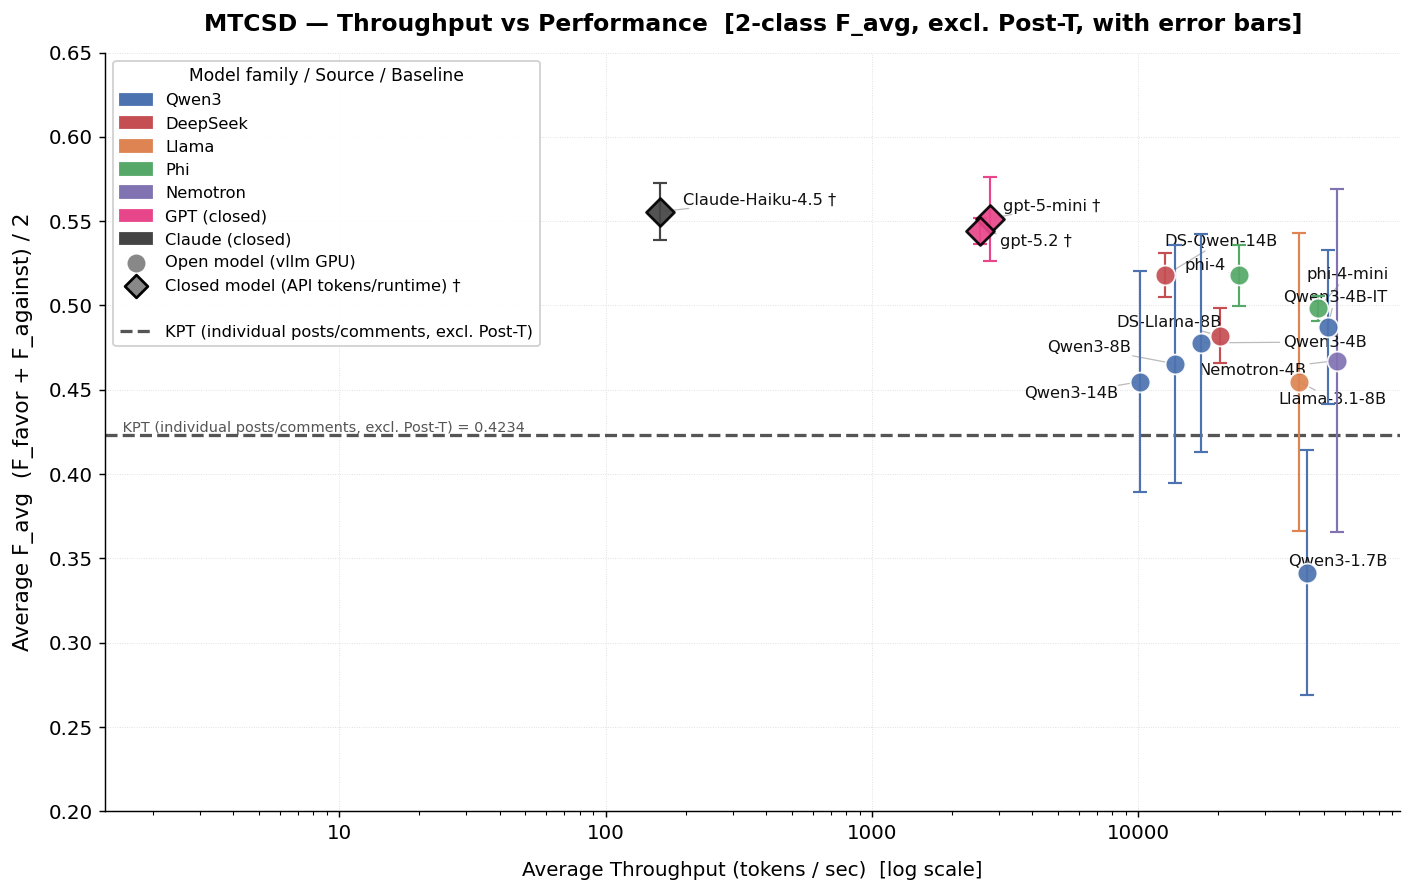

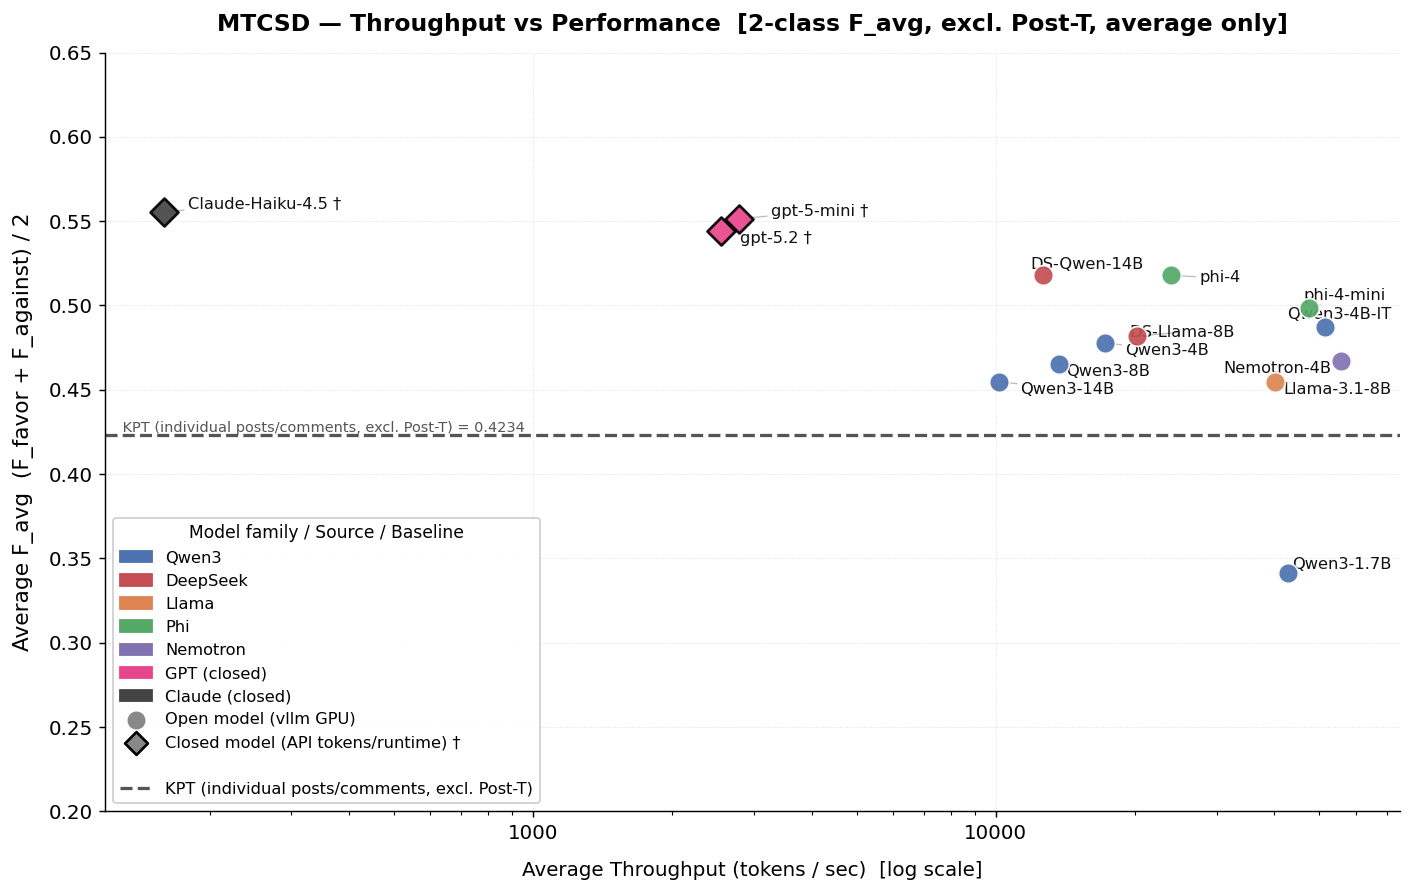

Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/mtcsd_favg_co2_f1.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/mtcsd_favg_co2_f1_clean.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/mtcsd_favg_throughput_f1.pdf
Saved: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/mtcsd_favg_throughput_f1_clean.pdf
All 4 MTCSD F_avg figures saved.


In [17]:
def plot_mtcsd_favg_throughput(stats_df=None, ax=None, save_path=None, error_bars=True):
    """Throughput vs F_avg scatter for MTCSD. error_bars draws ±1 std on Y axis."""
    if stats_df is None:
        stats_df = mtcsd_favg_stats

    subset = stats_df[stats_df['avg_throughput'].notna()].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 7))
    else:
        fig = ax.get_figure()

    ax.set_xscale('log')

    baseline_handles = _draw_favg_baselines(ax)

    texts = []
    for _, row in subset.iterrows():
        marker    = 'D' if not row['is_open'] else 'o'
        edgecolor = 'black' if not row['is_open'] else 'white'
        linewidth = 1.5 if not row['is_open'] else 1.0

        if error_bars:
            ax.errorbar(
                row['avg_throughput'], row['avg_favg'],
                yerr=row['std_favg'],
                fmt='none', color=row['color'],
                capsize=4, capthick=1.2, elinewidth=1.2, zorder=3,
            )
        ax.scatter(row['avg_throughput'], row['avg_favg'],
                   s=120, color=row['color'], marker=marker,
                   edgecolors=edgecolor, linewidths=linewidth,
                   alpha=0.92, zorder=4)
        texts.append(ax.text(row['avg_throughput'], row['avg_favg'],
                             row['label'], fontsize=9, color='#111'))

    adjust_text(texts, ax=ax, expand=(1.4, 1.8),
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7))

    ax.set_ylim(FAVG_YMIN, FAVG_YMAX)
    ax.set_yticks(FAVG_YTICKS)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='x')

    title_eb = 'with error bars' if error_bars else 'average only'
    ax.set_ylabel('Average F_avg  (F_favor + F_against) / 2', fontsize=12, labelpad=8)
    ax.set_xlabel('Average Throughput (tokens / sec)  [log scale]', fontsize=11, labelpad=10)
    ax.set_title(f'MTCSD — Throughput vs Performance  [2-class F_avg, excl. Post-T, {title_eb}]',
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.4, color='#aaa')
    ax.spines[['top', 'right']].set_visible(False)

    families_present = subset['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in families_present
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (vllm GPU)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (API tokens/runtime) †'),
    ]
    ax.legend(handles=family_handles + marker_handles + [mpatches.Patch(color='none', label='')] + baseline_handles,
              fontsize=9, title='Model family / Source / Baseline', title_fontsize=9.5,
              loc='best', framealpha=0.9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f'Saved: {save_path}')
    return fig, ax


fig, ax = plot_mtcsd_favg_throughput(error_bars=True)
plt.show()

fig, ax = plot_mtcsd_favg_throughput(error_bars=False)
plt.show()


# ── Save all 4 MTCSD F_avg figures to PDF ─────────────────────────────────────
OUT_DIR = '/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper'

plot_mtcsd_favg_co2(error_bars=True,  save_path=f'{OUT_DIR}/mtcsd_favg_co2_f1.pdf')
plt.close()
plot_mtcsd_favg_co2(error_bars=False, save_path=f'{OUT_DIR}/mtcsd_favg_co2_f1_clean.pdf')
plt.close()
plot_mtcsd_favg_throughput(error_bars=True,  save_path=f'{OUT_DIR}/mtcsd_favg_throughput_f1.pdf')
plt.close()
plot_mtcsd_favg_throughput(error_bars=False, save_path=f'{OUT_DIR}/mtcsd_favg_throughput_f1_clean.pdf')
plt.close()
print('All 4 MTCSD F_avg figures saved.')

---
## 10. Extrapolation to Deployment Scale (1M Documents)

**Goal**: same scatter-plot format as Section 6 (CO₂eq vs Macro F1), with the x-axis rescaled from
"total CO₂eq for this one test-set run" to "CO₂eq for a hypothetical 1,000,000-document deployment."
The y-axis (F1) is **unchanged** — F1 is an intensive quantity (a rate) that does not grow with deployment
volume, whereas CO₂ is an extensive quantity (a total) that does. Units stay in **grams CO₂eq**, matching
Section 6, just rescaled to the larger volume.

### Formulas

1. **Per-document carbon cost** (g CO₂eq / doc), computed separately per `(dataset, model)`:

   ```
   co2_g_per_doc = avg_co2_g / num_examples
   ```

   where `avg_co2_g` is the per-run total CO₂eq already computed in `model_stats` (averaged across
   prompt strategies — CarbonTracker for open models, EcoLogits midpoint estimate for closed models),
   and `num_examples` is the fixed size of that dataset's test set (SemEval 2016 = 1,249;
   MTCSD = 2,371; EZStance-NP = 2,663).

2. **Extrapolated cost at 1M-document scale** (g CO₂eq / 1M docs):

   ```
   co2_g_per_1M_docs = co2_g_per_doc × 1,000,000
   ```

   This assumes **constant marginal cost per document** — no economies of scale, no batching speed-up,
   no degradation at higher volume. Standard simplifying assumption for inference-time extrapolation
   in the carbon-footprint literature (Strubell et al. 2019; Henderson et al. 2020; Patterson et al.
   2021) — verify exact citation details before camera-ready.

### Caveat carried over from Section 6

Per-document cost is **not stable across datasets for the same model** — SemEval's per-doc rate runs
roughly 2x MTCSD/EZStance's for almost every model, plausibly because SemEval's smaller test set
(1,249 docs) amortizes a fixed per-run overhead (model loading, vLLM warm-up) over fewer documents.
Reported per-dataset, not pooled, so this is visible rather than averaged away.

In [ ]:
# ── Extrapolation table ────────────────────────────────────────────────────
# co2_g_per_doc      = avg_co2_g / num_examples
# co2_g_per_1M_docs  = co2_g_per_doc * 1,000,000

NUM_EXAMPLES = {
    'SemEval 2016': 1249,
    'MTCSD':        2371,
    'EZStance':     2663,
}

extrap = model_stats.copy()
extrap['num_examples']      = extrap['dataset'].map(NUM_EXAMPLES)
extrap['co2_g_per_doc']     = extrap['avg_co2_g'] / extrap['num_examples']
extrap['co2_g_per_1M_docs'] = extrap['co2_g_per_doc'] * 1_000_000

extrap = extrap[['dataset','model','label','family','color','is_open',
                  'avg_f1','std_f1','avg_co2_g','num_examples',
                  'co2_g_per_doc','co2_g_per_1M_docs']].copy()

print(f"Rows: {len(extrap)}  |  Models: {extrap['model'].nunique()}  |  Datasets: {extrap['dataset'].nunique()}")
extrap.head()

### Per-dataset extrapolation tables (sorted by carbon cost, ascending)

In [ ]:
for ds in ['SemEval 2016', 'MTCSD', 'EZStance']:
    sub = (extrap[extrap['dataset'] == ds]
           .sort_values('co2_g_per_1M_docs')
           .reset_index(drop=True))
    print(f"\n=== {ds} ===")
    display(
        sub[['label','family','is_open','avg_f1','co2_g_per_doc','co2_g_per_1M_docs']]
        .style.format({'avg_f1':'{:.3f}','co2_g_per_doc':'{:.5f}','co2_g_per_1M_docs':'{:,.0f}'})
    )

### Visualization — same scatter format as Section 6, x-axis rescaled to 1M-doc deployment

In [ ]:
# Same visual language as plot_co2_vs_f1 (Section 6): dots = open models, diamonds = closed,
# colored by family, ±1 std error bars, supervised-baseline dashed lines, adjustText labels.
# Only difference: x-axis is co2_g_per_1M_docs (log scale — values run ~150g to ~22,000g,
# comfortably above zero, so no symlog/linear region is needed here unlike Section 6).

EXTRAP_XMIN, EXTRAP_XMAX = 100, 30000
EXTRAP_XTICKS = [100, 200, 500, 1000, 2000, 5000, 10000, 20000]


def plot_extrapolated(dataset_name, ax=None, error_bars=True):
    subset = extrap[
        (extrap['dataset'] == dataset_name) &
        extrap['co2_g_per_1M_docs'].notna()
    ].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 7))
    else:
        fig = ax.get_figure()

    ax.set_xscale('log')
    ax.set_xlim(EXTRAP_XMIN, EXTRAP_XMAX)
    ax.set_xticks(EXTRAP_XTICKS)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    # ── Supervised baseline lines (reuse Section 6 baselines) ────────────────
    baseline_handles = []
    for label, value in SUPERVISED_BASELINES.get(dataset_name, []):
        ax.axhline(value, linestyle=':', linewidth=1.8, color='#555', zorder=2)
        ax.text(0.01, value, f' {label} = {value:.3f}',
                transform=ax.get_yaxis_transform(),
                fontsize=8, color='#555', va='bottom')
        baseline_handles.append(
            plt.Line2D([0], [0], linestyle=':', color='#555', linewidth=1.8, label=label)
        )

    # ── Model scatter points ──────────────────────────────────────────────────
    texts = []
    for _, row in subset.iterrows():
        marker    = 'D' if not row['is_open'] else 'o'
        edgecolor = 'black' if not row['is_open'] else 'white'
        linewidth = 1.5 if not row['is_open'] else 1.0

        if error_bars:
            ax.errorbar(
                row['co2_g_per_1M_docs'], row['avg_f1'],
                yerr=row['std_f1'],
                fmt='none', color=row['color'],
                capsize=4, capthick=1.2, elinewidth=1.2, zorder=3,
            )
        ax.scatter(
            row['co2_g_per_1M_docs'], row['avg_f1'],
            s=120, color=row['color'], marker=marker,
            edgecolors=edgecolor, linewidths=linewidth,
            alpha=0.92, zorder=4,
        )
        texts.append(ax.text(row['co2_g_per_1M_docs'], row['avg_f1'], row['label'],
                             fontsize=9, color='#111'))

    adjust_text(texts, ax=ax, expand=(1.4, 1.8),
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7))

    ax.set_ylim(GLOBAL_YMIN, GLOBAL_YMAX)
    ax.set_yticks(GLOBAL_YTICKS)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

    ax.set_ylabel('Average 3-class Macro F1', fontsize=12, labelpad=8)
    ax.set_title(f'{dataset_name} — Performance vs Carbon Cost at 1M-doc Scale',
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.4, color='#aaa')
    ax.spines[['top', 'right']].set_visible(False)

    ax.set_xlabel(
        'Extrapolated CO₂eq per 1,000,000 docs (g CO₂eq, log scale)\n'
        'linear extrapolation from measured per-doc cost  ·  closed-model CO₂ via EcoLogits',
        fontsize=10, labelpad=10,
    )

    families_present = subset['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in families_present
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (CarbonTracker)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (EcoLogits estimate) †'),
    ]
    all_handles = family_handles + marker_handles
    if baseline_handles:
        all_handles += [mpatches.Patch(color='none', label='')] + baseline_handles
    ax.legend(handles=all_handles, fontsize=9, loc='best', framealpha=0.9)

    return fig, ax


# ── SemEval 2016 — own figure (main text) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
plot_extrapolated('SemEval 2016', ax=ax)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/extrapolation_1M_semeval.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR}/extrapolation_1M_semeval.pdf")

# ── EZStance — own figure (appendix) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
plot_extrapolated('EZStance', ax=ax)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/extrapolation_1M_ezstance.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR}/extrapolation_1M_ezstance.pdf")

# ── MTCSD — own figure (appendix), using the paper-comparable F_avg metric ───
# (F_avg = (F_favor + F_against) / 2, NONE excluded) instead of 3-class macro F1,
# so it can be read against the KPT baseline from the MT2-CSD paper.
extrap_favg = mtcsd_favg_stats.copy()
extrap_favg['num_examples']      = 2371
extrap_favg['co2_g_per_doc']     = extrap_favg['avg_co2_g'] / extrap_favg['num_examples']
extrap_favg['co2_g_per_1M_docs'] = extrap_favg['co2_g_per_doc'] * 1_000_000


def plot_extrapolated_favg(ax=None, error_bars=True):
    subset = extrap_favg[extrap_favg['co2_g_per_1M_docs'].notna()].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.get_figure()

    ax.set_xscale('log')
    ax.set_xlim(EXTRAP_XMIN, EXTRAP_XMAX)
    ax.set_xticks(EXTRAP_XTICKS)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    baseline_handles = _draw_favg_baselines(ax)

    texts = []
    for _, row in subset.iterrows():
        marker    = 'D' if not row['is_open'] else 'o'
        edgecolor = 'black' if not row['is_open'] else 'white'
        linewidth = 1.5 if not row['is_open'] else 1.0

        if error_bars:
            ax.errorbar(
                row['co2_g_per_1M_docs'], row['avg_favg'],
                yerr=row['std_favg'],
                fmt='none', color=row['color'],
                capsize=4, capthick=1.2, elinewidth=1.2, zorder=3,
            )
        ax.scatter(
            row['co2_g_per_1M_docs'], row['avg_favg'],
            s=120, color=row['color'], marker=marker,
            edgecolors=edgecolor, linewidths=linewidth,
            alpha=0.92, zorder=4,
        )
        texts.append(ax.text(row['co2_g_per_1M_docs'], row['avg_favg'], row['label'],
                             fontsize=9, color='#111'))

    adjust_text(texts, ax=ax, expand=(1.4, 1.8),
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.7))

    ax.set_ylim(FAVG_YMIN, FAVG_YMAX)
    ax.set_yticks(FAVG_YTICKS)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

    ax.set_ylabel('Average F_avg  (F_favor + F_against) / 2', fontsize=12, labelpad=8)
    ax.set_title('MTCSD — Performance vs Carbon Cost at 1M-doc Scale [F_avg]',
                 fontsize=13, fontweight='bold', pad=12)
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, alpha=0.4, color='#aaa')
    ax.spines[['top', 'right']].set_visible(False)

    ax.set_xlabel(
        'Extrapolated CO₂eq per 1,000,000 docs (g CO₂eq, log scale)\n'
        'linear extrapolation from measured per-doc cost  ·  closed-model CO₂ via EcoLogits',
        fontsize=10, labelpad=10,
    )

    families_present = subset['family'].unique()
    family_handles = [
        mpatches.Patch(color=FAMILY_COLORS[f], label=f)
        for f in FAMILY_COLORS if f in families_present
    ]
    marker_handles = [
        plt.scatter([], [], s=80, marker='o', color='#888', label='Open model (CarbonTracker)'),
        plt.scatter([], [], s=80, marker='D', color='#888', edgecolors='black',
                    linewidths=1.5, label='Closed model (EcoLogits estimate) †'),
    ]
    all_handles = family_handles + marker_handles
    if baseline_handles:
        all_handles += [mpatches.Patch(color='none', label='')] + baseline_handles
    ax.legend(handles=all_handles, fontsize=9, loc='best', framealpha=0.9)

    return fig, ax


fig, ax = plot_extrapolated_favg()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/extrapolation_1M_mtcsd_favg.pdf', bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR}/extrapolation_1M_mtcsd_favg.pdf")

---
## ACL Single-Column Options — EZStance demo (3.3" wide)

Three approaches to fitting the CO₂ vs F1 scatter in a single ACL column.  
Run each cell independently; all depend on `model_stats` and config from cells above.

In [ ]:
# ── Option A: numbered points + 2-column legend below ────────────────────────
# Each point is a numbered annotation box; legend table sits below the axes.
import matplotlib.gridspec as gridspec

_DS  = 'EZStance'
_sub = model_stats[
    (model_stats['dataset'] == _DS) & model_stats['avg_co2_g'].notna()
].copy().sort_values('avg_co2_g').reset_index(drop=True)

fig = plt.figure(figsize=(3.3, 5.6))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3.2, 1.5], hspace=0.06,
                        top=0.93, bottom=0.05, left=0.14, right=0.97)
ax     = fig.add_subplot(gs[0])
ax_leg = fig.add_subplot(gs[1])

ax.set_xscale('log')
for label, value in SUPERVISED_BASELINES.get(_DS, []):
    ax.axhline(value, linestyle=':', lw=1.3, color='#555', zorder=2)
    ax.text(0.02, value + 0.003, label.split('(')[0].strip(),
            transform=ax.get_yaxis_transform(), fontsize=5.5, color='#555', va='bottom')

for i, row in _sub.iterrows():
    n = i + 1
    closed = not row['is_open']
    ax.errorbar(row['avg_co2_g'], row['avg_f1'], yerr=row['std_f1'],
                fmt='none', color=row['color'], capsize=2, elinewidth=0.7, zorder=3)
    ax.scatter(row['avg_co2_g'], row['avg_f1'], s=220, zorder=4,
               color=row['color'], marker='D' if closed else 'o',
               edgecolors='black' if closed else row['color'], linewidths=0.8)
    ax.text(row['avg_co2_g'], row['avg_f1'], str(n),
            ha='center', va='center', fontsize=5.5, fontweight='bold',
            color='white', zorder=5)

ax.set_xlabel('Extrapolated CO₂eq/1M docs (g, log)', fontsize=7, fontweight='bold')
ax.set_ylabel('Avg Macro F1', fontsize=7, fontweight='bold')
ax.set_title(f'{_DS} — CO₂eq vs F1', fontsize=8, fontweight='bold', pad=4)
ax.tick_params(labelsize=6)
ax.set_ylim(0.42, 0.73)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

# 2-column legend table
ax_leg.axis('off')
n_models = len(_sub)
half = (n_models + 1) // 2
for i, row in _sub.iterrows():
    col = 0 if i < half else 1
    r   = i if i < half else i - half
    x   = 0.01 + col * 0.50
    y   = 1.0 - r * (1.0 / half)
    ax_leg.text(x, y, f'{i+1}. {row["label"]}',
                fontsize=6, fontweight='bold', va='top', color=row['color'],
                transform=ax_leg.transAxes)

plt.savefig('/tmp/acl_option_a.png', dpi=200, bbox_inches='tight')
plt.show()
print("Option A saved to /tmp/acl_option_a.png")

In [ ]:
# ── Option B (v2): short inline labels, 1M-doc scale — all three datasets ────
from adjustText import adjust_text
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

_SHORT_B = {
    'claude-haiku-4-5-20251001':    'Haiku-4.5 †',
    'gpt-5-mini':                   'GPT-5-mini †',
    'gpt-5.2':                      'GPT-5.2 †',
    'phi-4':                        'Phi-4',
    'phi-4-mini-instruct':          'Phi-4-mini',
    'Qwen3-1.7B':                   'Qwen3-1.7B',
    'Qwen3-4B':                     'Qwen3-4B',
    'Qwen3-4B-Instruct-2507':       'Qwen3-4B-IT',
    'Qwen3-8B':                     'Qwen3-8B',
    'Qwen3-14B':                    'Qwen3-14B',
    'DeepSeek-R1-Distill-Llama-8B': 'DS-Llama-8B',
    'DeepSeek-R1-Distill-Qwen-14B': 'DS-Qwen-14B',
    'Llama-3.1-8B-Instruct':        'Llama-3.1-8B',
    'Nemotron-Mini-4B-Instruct':    'Nemotron-4B',
}

_BASELINE_SHORT = {
    'SVM n-grams (Mohammad et al. 2016)':       'SVM n-grams (2016)',
    'BART-MNLI-ep fine-tuned (EZStance paper)': 'BART-MNLI-ep (EZStance)',
}

_XTICKS  = [100, 200, 500, 1000, 2000, 5000, 10000, 20000]
_fmt_x   = lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v))

def _plot_acl_b(dataset_name, save_path=None):
    _sub = extrap[
        (extrap['dataset'] == dataset_name) & extrap['co2_g_per_1M_docs'].notna()
    ].copy().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(3.3, 3.8))
    ax.set_xscale('log')
    ax.set_xlim(80, 35000)
    ax.set_xticks(_XTICKS)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_fmt_x))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    for label, value in SUPERVISED_BASELINES.get(dataset_name, []):
        ax.axhline(value, linestyle=':', lw=1.3, color='#555', zorder=2)
        short = _BASELINE_SHORT.get(label, label)
        ax.text(0.02, value + 0.003, short,
                transform=ax.get_yaxis_transform(), fontsize=5.5, color='#555', va='bottom')

    texts = []
    for _, row in _sub.iterrows():
        closed = not row['is_open']
        ax.errorbar(row['co2_g_per_1M_docs'], row['avg_f1'], yerr=row['std_f1'],
                    fmt='none', color=row['color'], capsize=2, elinewidth=0.7, zorder=3)
        ax.scatter(row['co2_g_per_1M_docs'], row['avg_f1'], s=32, zorder=4,
                   color=row['color'], marker='D' if closed else 'o',
                   edgecolors='black' if closed else row['color'], linewidths=0.8)
        lbl = _SHORT_B.get(row['model'], row['label'])
        texts.append(ax.text(row['co2_g_per_1M_docs'], row['avg_f1'], lbl,
                             fontsize=5.8, fontweight='bold', color=row['color']))

    adjust_text(texts, ax=ax, expand=(1.5, 2.0),
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.5))

    ax.set_xlabel('CO₂eq per 1M docs (g)', fontsize=7, fontweight='bold')
    ax.set_ylabel('Avg Macro F1', fontsize=7, fontweight='bold')
    ax.set_title(f'{dataset_name} — Performance vs Carbon Cost\n(extrapolated to 1M-doc scale)',
                 fontsize=8, fontweight='bold', pad=4)
    ax.tick_params(labelsize=6.5)
    ax.set_ylim(GLOBAL_YMIN, GLOBAL_YMAX)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.grid(True, which='major', alpha=0.2, linestyle='--', linewidth=0.5)

    handles = [mpatches.Patch(color=FAMILY_COLORS[f], label=f)
               for f in FAMILY_COLORS if f in _sub['family'].values]
    ax.legend(handles=handles, fontsize=5, ncol=2, loc='lower right',
              framealpha=0.85, handlelength=1, handleheight=0.8,
              borderpad=0.4, labelspacing=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()

for _ds in ['SemEval 2016', 'EZStance', 'MTCSD']:
    _plot_acl_b(_ds)

In [ ]:
# ── Option C: horizontal dot-strip — models on Y, CO₂ on X, F1 as color ─────
# Models sorted by CO₂ (cheapest at top). F1 encoded in dot color (RdYlGn).
# No label crowding; closed models marked with a black ring.
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

_DS  = 'EZStance'
_sub = model_stats[
    (model_stats['dataset'] == _DS) & model_stats['avg_co2_g'].notna()
].copy().sort_values('avg_co2_g').reset_index(drop=True)

_SHORT = {
    'claude-haiku-4-5-20251001':    'Haiku-4.5 †',
    'gpt-5-mini':                   'GPT-5-mini †',
    'gpt-5.2':                      'GPT-5.2 †',
    'phi-4':                        'phi-4',
    'phi-4-mini-instruct':          'phi-4-mini',
    'Qwen3-1.7B':                   'Q3-1.7B',
    'Qwen3-4B':                     'Q3-4B',
    'Qwen3-4B-Instruct-2507':       'Q3-4B-IT',
    'Qwen3-8B':                     'Q3-8B',
    'Qwen3-14B':                    'Q3-14B',
    'DeepSeek-R1-Distill-Llama-8B': 'DS-Llama-8B',
    'DeepSeek-R1-Distill-Qwen-14B': 'DS-Qwen-14B',
    'Llama-3.1-8B-Instruct':        'Llama-3.1-8B',
    'Nemotron-Mini-4B-Instruct':    'Nemotron-4B',
}

_f1_min, _f1_max = _sub['avg_f1'].min(), _sub['avg_f1'].max()
_norm  = mcolors.Normalize(vmin=_f1_min - 0.02, vmax=_f1_max + 0.02)
_cmap  = cm.RdYlGn

_n = len(_sub)
fig, ax = plt.subplots(figsize=(3.3, max(2.8, _n * 0.27 + 0.5)))

ax.set_xscale('log')
ax.set_ylim(-0.5, _n - 0.5)
ax.invert_yaxis()

# faint horizontal grid lines
for i in range(_n):
    ax.axhline(i, color='#e8e8e8', lw=0.6, zorder=0)

# baseline vertical line
for label, value in SUPERVISED_BASELINES.get(_DS, []):
    pass  # baseline is F1 not CO2, doesn't apply here; skip

for i, row in _sub.iterrows():
    closed = not row['is_open']
    fc = _cmap(_norm(row['avg_f1']))
    ec = 'black' if closed else '#555'
    lw = 1.5 if closed else 0.6
    ax.scatter(row['avg_co2_g'], i, s=90, color=fc,
               edgecolors=ec, linewidths=lw, zorder=3, marker='D' if closed else 'o')
    # error bar on x (CO2 std is 0 since it's a mean; show nothing) — skip
    lbl = _SHORT.get(row['model'], row['label'])
    ax.text(-0.02, i, lbl, ha='right', va='center', fontsize=6,
            fontweight='bold', color='#222',
            transform=ax.get_yaxis_transform())

ax.set_yticks([])
ax.set_xlabel('Extrapolated CO₂eq / 1M docs (g, log scale)', fontsize=7, fontweight='bold')
ax.set_title(f'{_DS} — Cost vs Performance', fontsize=8, fontweight='bold', pad=4)
ax.tick_params(axis='x', labelsize=6)

# Colorbar for F1
sm = cm.ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.06, pad=0.02)
cbar.set_label('Macro F1', fontsize=6.5, fontweight='bold')
cbar.ax.tick_params(labelsize=6)

# Marker legend
_open_h  = plt.scatter([], [], s=60, marker='o', color='#aaa', edgecolors='#555', lw=0.6, label='Open (CarbonTracker)')
_clos_h  = plt.scatter([], [], s=60, marker='D', color='#aaa', edgecolors='black', lw=1.5, label='Closed (EcoLogits) †')
ax.legend(handles=[_open_h, _clos_h], fontsize=5.5, loc='lower right',
          framealpha=0.85, handletextpad=0.4)

plt.tight_layout()
plt.savefig('/tmp/acl_option_c.png', dpi=200, bbox_inches='tight')
plt.show()
print("Option C saved to /tmp/acl_option_c.png")

---
## Appendix: Per-Prompt Macro F1 Tables

One table per dataset. Rows = models (family-grouped), columns = prompt strategies.  
SemEval excludes semantic ICL prompts.

In [ ]:
# ── Appendix: per-prompt Macro F1 tables ─────────────────────────────────────
from IPython.display import display, HTML
import pandas as pd

_FAMILY_ORDER = ['Qwen3','DeepSeek','Llama','Phi','Nemotron','GPT (closed)','Claude (closed)']
_SIZE_MAP = {
    'Qwen3-1.7B':1.7,'Qwen3-4B':4,'Qwen3-4B-Instruct-2507':4.1,'Qwen3-8B':8,'Qwen3-14B':14,
    'DeepSeek-R1-Distill-Llama-8B':8,'DeepSeek-R1-Distill-Qwen-14B':14,
    'Llama-3.1-8B-Instruct':8,'phi-4':14,'phi-4-mini-instruct':3.8,
    'Nemotron-Mini-4B-Instruct':4,'gpt-5-mini':100,'gpt-5.2':101,'claude-haiku-4-5-20251001':102,
}
_SHORT_NAME = {
    'Qwen3-1.7B':'Qwen3-1.7B','Qwen3-4B':'Qwen3-4B','Qwen3-4B-Instruct-2507':'Qwen3-4B-IT',
    'Qwen3-8B':'Qwen3-8B','Qwen3-14B':'Qwen3-14B',
    'DeepSeek-R1-Distill-Llama-8B':'DS-Llama-8B','DeepSeek-R1-Distill-Qwen-14B':'DS-Qwen-14B',
    'Llama-3.1-8B-Instruct':'Llama-3.1-8B','phi-4':'Phi-4','phi-4-mini-instruct':'Phi-4-mini',
    'Nemotron-Mini-4B-Instruct':'Nemotron-4B',
    'gpt-5-mini':'GPT-5-mini †','gpt-5.2':'GPT-5.2 †','claude-haiku-4-5-20251001':'Haiku-4.5 †',
}

# Prompt groups and short labels
_ZS = ['default_no_label_definitions','default','task_definition','task_definition_scale','question','cot']
_FS = ['few_shot_3','few_shot_6','few_shot_9','few_shot_12','few_shot_15']
_FS_SEMEVAL_ONLY = ['few_shot']   # SemEval legacy single few-shot prompt

_PROMPT_SHORT = {
    'default_no_label_definitions': 'default-nld',
    'default':                      'default',
    'task_definition':              'task-def',
    'task_definition_scale':        'task-def-s',
    'question':                     'question',
    'cot':                          'cot',
    'few_shot':                     'FS',
    'few_shot_3':                   'FS-3','few_shot_6':'FS-6','few_shot_9':'FS-9',
    'few_shot_12':                  'FS-12','few_shot_15':'FS-15',
}

_PROMPT_ORDER = {
    'SemEval 2016': _ZS + _FS_SEMEVAL_ONLY + _FS,
    'EZStance':     _ZS + _FS,
    'MTCSD':        _ZS + _FS,
}

def _model_sort_key(m):
    fam = MODEL_FAMILY.get(m, 'Other')
    fi  = _FAMILY_ORDER.index(fam) if fam in _FAMILY_ORDER else 99
    return (fi, _SIZE_MAP.get(m, 0))

def _make_table(ds):
    sub = all_runs[all_runs['dataset'] == ds].copy()
    valid_prompts = _PROMPT_ORDER[ds]
    sub = sub[sub['prompt'].isin(valid_prompts)]

    pivot = sub.pivot_table(
        index='model', columns='prompt', values='macro_f1', aggfunc='mean'
    )
    # reorder columns to match prompt order
    pivot = pivot.reindex(columns=[p for p in valid_prompts if p in pivot.columns])
    pivot.columns = [_PROMPT_SHORT.get(c, c) for c in pivot.columns]

    # reorder rows by family then size
    pivot = pivot.loc[sorted(pivot.index, key=_model_sort_key)]
    pivot.index = [_SHORT_NAME.get(m, m) for m in pivot.index]

    return pivot

def _render(ds, pivot):
    best_val = pivot.values[~pd.isna(pivot.values)].max()

    def _fmt(v):
        if pd.isna(v): return '—'
        s = f'{v:.3f}'
        return f'<b>{s}</b>' if abs(v - best_val) < 1e-5 else s

    col_groups = []
    zs_cols = [_PROMPT_SHORT.get(p,p) for p in (_ZS + (_FS_SEMEVAL_ONLY if ds=='SemEval 2016' else [])) if _PROMPT_SHORT.get(p,p) in pivot.columns]
    fs_cols = [_PROMPT_SHORT.get(p,p) for p in _FS if _PROMPT_SHORT.get(p,p) in pivot.columns]

    n_zs = len(zs_cols)
    n_fs = len(fs_cols)

    header1 = '<tr style="border-bottom:1px solid #bbb">'
    header1 += '<th rowspan="2" style="text-align:left;padding:4px 8px;font-size:11px">Model</th>'
    if n_zs: header1 += f'<th colspan="{n_zs}" style="text-align:center;padding:4px 8px;font-size:11px;background:#f5f5f5">Zero-shot</th>'
    if n_fs: header1 += f'<th colspan="{n_fs}" style="text-align:center;padding:4px 8px;font-size:11px;background:#e8f4e8">Random ICL</th>'
    header1 += '</tr>'

    header2 = '<tr style="border-bottom:2px solid #555">'
    for c in pivot.columns:
        bg = '#f5f5f5' if c in zs_cols else '#e8f4e8'
        header2 += f'<th style="text-align:center;padding:3px 6px;font-size:10px;background:{bg}">{c}</th>'
    header2 += '</tr>'

    rows_html = []
    prev_fam = None
    for model_name, row in pivot.iterrows():
        # recover original model key for family lookup
        orig = next((k for k,v in _SHORT_NAME.items() if v == model_name), model_name)
        fam = MODEL_FAMILY.get(orig, 'Other')
        if fam != prev_fam:
            ncols = len(pivot.columns) + 1
            rows_html.append(
                f'<tr><td colspan="{ncols}" style="background:#efefef;font-weight:bold;'
                f'font-size:10px;padding:2px 8px;font-style:italic">{fam}</td></tr>')
            prev_fam = fam
        cells = ''.join(
            f'<td style="text-align:center;padding:2px 6px;font-size:10px">{_fmt(row[c])}</td>'
            for c in pivot.columns)
        rows_html.append(
            f'<tr><td style="padding:2px 8px;font-size:10px;white-space:nowrap">{model_name}</td>{cells}</tr>')

    ds_title = {'SemEval 2016':'SemEval 2016 Task 6','EZStance':'EZStance','MTCSD':'MTCSD'}[ds]
    html = (
        f'<table style="border-collapse:collapse;margin-bottom:24px">'
        f'<caption style="font-weight:bold;font-size:12px;text-align:left;padding-bottom:6px">'
        f'{ds_title} — Macro F1 per model × prompt</caption>'
        f'<thead>{header1}{header2}</thead>'
        f'<tbody>{"".join(rows_html)}</tbody>'
        f'<tfoot><tr><td colspan="{len(pivot.columns)+1}" style="font-size:9px;color:#666;padding:4px 8px">'
        f'† Closed model (API). <b>Bold</b> = highest F1 in table.</td></tr></tfoot>'
        f'</table>'
    )
    display(HTML(html))

for ds in ['SemEval 2016', 'EZStance', 'MTCSD']:
    pivot = _make_table(ds)
    _render(ds, pivot)
